# Predicting Drug Therapeutic Classes Using Machine Learning
### Team 4 — Priyanka Vadivel & Adharsh Rengarajan
### INFO 6105 — Data Science | Spring 2026 | Northeastern University

---

**Project Goal:** Build a multi-class text classification model to predict the therapeutic class of a drug based on its textual and categorical information from the MID (Medicines Information Dataset).

**Dataset:** [Kaggle - Medical Information Dataset](https://www.kaggle.com/datasets/imtkaggleteam/medical-information-dataset) | 192K+ rows, 15 columns, 22 therapeutic classes

**Best Result:** Random Forest — 99.79% accuracy, 0.9979 weighted F1-score

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from collections import Counter

In [2]:
# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [3]:
# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             f1_score, precision_score, recall_score, roc_auc_score)
from sklearn.pipeline import Pipeline
from scipy.sparse import hstack

import xgboost as xgb
from wordcloud import WordCloud

In [4]:
# NLTK Downloads
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)


True

In [5]:
# Settings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

In [6]:
print("All imports successful!")

All imports successful!


## 2. Data Loading & Initial Exploration <a id="2-data-loading--initial-exploration"></a>

In [7]:
DATA_PATH = "MID.xlsx"

# Load the dataset
print("Loading dataset... (this may take a minute for 198MB)")
df = pd.read_excel(DATA_PATH, engine='openpyxl')
print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Loading dataset... (this may take a minute for 198MB)
Dataset loaded successfully!
Shape: 192,807 rows × 15 columns
Memory usage: 1197.2 MB


In [8]:
df.head()


,Name,Link,Contains,ProductIntroduction,ProductUses,ProductBenefits,SideEffect,HowToUse,HowWorks,QuickTips,SafetyAdvice,Chemical_Class,Habit_Forming,Therapeutic_Class,Action_Class
0,Andol 0.5mg Tablet,https://www.1mg.com/drugs/andol-0.5mg-tablet-698655,Haloperidol (0.5mg),"Andol 0.5mg Tablet can also be used for treating psychosis, mania, severe behavior problems in a...","\n \n \nul \""\""\n\n \n 0\n\n \n Schizophrenia\n \n \n \n \n \n",\n \n Schizophrenia \n \n Schizophrenia is a mental disorder in which a person’s thinking abi...,Most side effects do not require any medical attention and disappear as your body adjusts to the...,Take this medicine in the dose and duration as advised by your doctor. Swallow it as a whole. Do...,"Andol 0.5mg Tablet is a typical antipsychotic. It works by blocking the action of dopamine, a ch...",\n \n Andol 0.5mg Tablet helps treat schizophrenia. \n \n It is less likely to cause weight ga...,"\nAlcohol\n,\nAndol 0.5mg Tablet may cause excessive drowsiness with alcohol.,\nPregnancy\n,\nAn...",Butyrophenone Derivative,No,NEURO CNS,Typical Antipsychotic
1,Avastin 100mg Injection,https://www.1mg.com/drugs/avastin-100mg-injection-135666,Bevacizumab (100mg),"\np dir=\""ltr\"" style=\""line-height: 1.38; margin-top: 0pt; margin-bottom: 0pt;\""\n\nspan style=...","\n \n \nul \""\""\n\n \n 0\n\n \n Cancer of colon and rectum\n \n \n \n \n 1\n\n ...","\n \n Cancer of colon and rectum \n \n Cancer of the colon and rectum, also known as colorect...",Most side effects do not require any medical attention and disappear as your body adjusts to the...,Your doctor or nurse will give you this medicine. Kindly do not self administer.,Avastin 100mg Injection is a anti-angiogenic medication. It works by blocking a protein called v...,"\n \n Avastin 100mg Injection is an effective, first-line option when used together with other...","\nAlcohol\n,\nIt is not known whether it is safe to consume alcohol with Avastin 100mg Injection...",Monoclonal antibody (mAb),No,ANTI NEOPLASTICS,Vascular endothelial growth factor (VEGF) inhibitor
2,Actorise 40 Injection,https://www.1mg.com/drugs/actorise-40-injection-227647,Darbepoetin alfa (40mcg),Actorise 40 Injection is a medicine that needs to be used with utmost care because it can lead t...,"\n \n \nul \""\""\n\n \n 0\n\n \n Treatment of Anemia due to chronic kidney disease\n ...",\n \n Treatment of Anemia due to chronic kidney disease \n \n Anemia is a condition where you...,Most side effects do not require any medical attention and disappear as your body adjusts to the...,Your doctor or nurse will give you this medicine. Kindly do not self administer.,Actorise 40 Injection is an erythropoiesis-stimulating agent (ESA). It works by stimulating the ...,\n \n Actorise 40 Injection helps in the treatment of anemia that may have occurred due to chr...,"\nAlcohol\n,\nIt is not known whether it is safe to consume alcohol with Actorise 40 Injection. ...","Amino Acids, Peptides Analogues",No,BLOOD RELATED,Erythropoiesis-stimulating agent (ESA
3,Actorise 25 Injection,https://www.1mg.com/drugs/actorise-25-injection-228329,Darbepoetin alfa (25mcg),Actorise 25 Injection is a medicine that needs to be used with utmost care because it can lead t...,"\n \n \nul \""\""\n\n \n 0\n\n \n Treatment of Anemia due to chronic kidney disease\n ...",\n \n Treatment of Anemia due to chronic kidney disease \n \n Anemia is a condition where you...,Most side effects do not require any medical attention and disappear as your body adjusts to the...,Your doctor or nurse will give you this medicine. Kindly do not self administer.,Actorise 25 Injection is an erythropoiesis-stimulating agent (ESA). It works by stimulating the ...,\n \n Actorise 25 Injection helps in the treatment of anemia that may have occurred due to chr...,"\nAlcohol\n,\nIt is not known whether it is safe to consume alcohol with Actorise 25 Injection. ...","Amino Acids, Peptides Analogues",No,BLOOD RELATED,Erythropoiesis-stimulating agent (E

In [9]:
# Column names and data types
print("=" * 60)
print("COLUMN INFORMATION")
print("=" * 60)
df.info()

COLUMN INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192807 entries, 0 to 192806
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Name                 192807 non-null  object
 1   Link                 192807 non-null  object
 2   Contains             192807 non-null  object
 3   ProductIntroduction  180821 non-null  object
 4   ProductUses          192807 non-null  object
 5   ProductBenefits      192807 non-null  object
 6   SideEffect           192807 non-null  object
 7   HowToUse             192712 non-null  object
 8   HowWorks             192571 non-null  object
 9   QuickTips            192807 non-null  object
 10  SafetyAdvice         192807 non-null  object
 11  Chemical_Class       101473 non-null  object
 12  Habit_Forming        192807 non-null  object
 13  Therapeutic_Class    192807 non-null  object
 14  Action_Class         85690 non-null   object
dtypes: object(15)
m

In [10]:
# Basic statistics for all columns
print("\nDataset shape:", df.shape)
print("\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col} (dtype: {df[col].dtype})")


Dataset shape: (192807, 15)

Column names:
   1. Name (dtype: object)
   2. Link (dtype: object)
   3. Contains (dtype: object)
   4. ProductIntroduction (dtype: object)
   5. ProductUses (dtype: object)
   6. ProductBenefits (dtype: object)
   7. SideEffect (dtype: object)
   8. HowToUse (dtype: object)
   9. HowWorks (dtype: object)
  10. QuickTips (dtype: object)
  11. SafetyAdvice (dtype: object)
  12. Chemical_Class (dtype: object)
  13. Habit_Forming (dtype: object)
  14. Therapeutic_Class (dtype: object)
  15. Action_Class (dtype: object)


In [11]:
# Missing values analysis
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values,
    'Dtype': df.dtypes.values
}).sort_values('Missing Count', ascending=False)
missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) > 0:
    print(f"\n{len(missing_df)} columns have missing values:\n")
    print(missing_df.to_string(index=False))
else:
    print("\nNo missing values found!")
    
print(f"\nTotal missing cells: {df.isnull().sum().sum():,} out of {df.shape[0] * df.shape[1]:,}")

MISSING VALUES ANALYSIS

5 columns have missing values:

             Column  Missing Count  Missing %  Dtype
       Action_Class         107117      55.56 object
     Chemical_Class          91334      47.37 object
ProductIntroduction          11986       6.22 object
           HowWorks            236       0.12 object
           HowToUse             95       0.05 object

Total missing cells: 210,768 out of 2,892,105


In [12]:
# Check for duplicate rows
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes:,} ({dupes/len(df)*100:.1f}%)")

# Quick fix — preview the actual target column
print(f"Target column: Therapeutic_Class")
print(f"Unique values: {df['Therapeutic_Class'].nunique()}")
print(f"\nValue counts (top 15):")
print(df['Therapeutic_Class'].value_counts().head(15))

Duplicate rows: 41,791 (21.7%)
Target column: Therapeutic_Class
Unique values: 44

Value counts (top 15):
Therapeutic_Class
ANTI INFECTIVES       20291
PAIN ANALGESIC        18861
RESPIRATOR            16392
GASTRO INTESTINA      15716
ANTI INFECTIVE        13333
NEURO CNS             11995
GASTRO INTESTINAL     11743
CARDIA                 8486
ANTI DIABETI           8466
NEURO CN               8125
CARDIAC                7190
PAIN ANALGESICS        5891
DERM                   5823
ANTI DIABETIC          4051
DERMA                  3868
Name: count, dtype: int64


### Key Observations from Initial Exploration

**Dataset Size:** 192,807 rows × 15 columns (1,174.4 MB in memory)

**Missing Values — 5 columns affected (210,768 total missing cells):**
| Column | Missing Count | Missing % |
|---|---|---|
| Action_Class | 107,117 | 55.56% |
| Chemical_Class | 91,334 | 47.37% |
| ProductIntroduction | 11,986 | 6.22% |
| HowWorks | 236 | 0.12% |
| HowToUse | 95 | 0.05% |

> Action_Class and Chemical_Class have nearly half their values missing. We will fill these with "Unknown" rather than dropping rows, to avoid losing over half the dataset.

**Duplicate Rows:** 41,791 rows (21.7% of the dataset) are exact duplicates and will be removed during cleaning.

**Target Variable (Therapeutic_Class):** Contains ~44 raw unique labels before cleaning. Many of these are near-duplicate spellings (e.g., "ANTI INFECTIVES" vs "ANTI INFECTIVE") that will be consolidated into ~22 clean classes in the next phase.

**Habit_Forming Distribution:** Overwhelmingly "No" (188,428) with a small "Yes" group (4,151), plus minor noise values ("~" = 223, "." = 5) that need cleaning.

In [13]:
# Fill missing categorical columns with 'Unknown' (not empty string)
df['Chemical_Class'].fillna('Unknown', inplace=True)
df['Action_Class'].fillna('Unknown', inplace=True)
print(f"Filled Chemical_Class and Action_Class missing values with 'Unknown'")

Filled Chemical_Class and Action_Class missing values with 'Unknown'


## 3. Data Cleaning & Label Consolidation <a id="3-data-cleaning--label-consolidation"></a>

The dataset has several quality issues we need to fix:
1. **Duplicate class labels** — 44 raw labels that are actually ~22 unique classes with spelling variations
2. **Duplicate rows** — exact row duplicates in the data
3. **HTML artifacts** — some text columns contain HTML tags and formatting
4. **Missing values** — some columns have null entries

### 3.1 Standardize Column Names

In [14]:
# Standardize column names (strip spaces, lowercase for consistency in code)
print("Original columns:", list(df.columns))

# Let's identify the actual column names from the data
# and create a clean mapping
col_mapping = {}
for col in df.columns:
    clean = col.strip()
    col_mapping[col] = clean
    
df.rename(columns=col_mapping, inplace=True)
print("\nCleaned columns:", list(df.columns))

Original columns: ['Name', 'Link', 'Contains', 'ProductIntroduction', 'ProductUses', 'ProductBenefits', 'SideEffect', 'HowToUse', 'HowWorks', 'QuickTips', 'SafetyAdvice', 'Chemical_Class', 'Habit_Forming', 'Therapeutic_Class', 'Action_Class']

Cleaned columns: ['Name', 'Link', 'Contains', 'ProductIntroduction', 'ProductUses', 'ProductBenefits', 'SideEffect', 'HowToUse', 'HowWorks', 'QuickTips', 'SafetyAdvice', 'Chemical_Class', 'Habit_Forming', 'Therapeutic_Class', 'Action_Class']


### 3.2 Merge Duplicate Therapeutic Class Labels

This is the most critical cleaning step. The dataset has 44 raw class labels, but many are near-duplicates with slight spelling differences.

In [15]:
# First, let's see ALL unique therapeutic class labels
# Identify the therapeutic class column
tc_col = [c for c in df.columns if 'therapeutic' in c.lower() or 'Therapeutic' in c][0]
print(f"Therapeutic class column: '{tc_col}'")
print(f"\nRaw unique classes: {df[tc_col].nunique()}")
print(f"\nAll labels (sorted):")
for i, label in enumerate(sorted(df[tc_col].dropna().unique()), 1):
    count = len(df[df[tc_col] == label])
    print(f"  {i:2d}. '{label}' ({count:,} rows)")

Therapeutic class column: 'Therapeutic_Class'

Raw unique classes: 44

All labels (sorted):
   1. '  ANTI DIABETI' (8,466 rows)
   2. '  ANTI DIABETIC ' (4,051 rows)
   3. '  ANTI INFECTIVE' (13,333 rows)
   4. '  ANTI INFECTIVES ' (20,291 rows)
   5. '  ANTI MALARIAL' (233 rows)
   6. '  ANTI MALARIALS ' (611 rows)
   7. '  ANTI NEOPLASTIC' (341 rows)
   8. '  ANTI NEOPLASTICS ' (2,537 rows)
   9. '  BLOOD RELATE' (986 rows)
  10. '  BLOOD RELATED ' (1,744 rows)
  11. '  CARDIA' (8,486 rows)
  12. '  CARDIAC ' (7,190 rows)
  13. '  DERM' (5,823 rows)
  14. '  DERMA ' (3,868 rows)
  15. '  GASTRO INTESTINA' (15,716 rows)
  16. '  GASTRO INTESTINAL ' (11,743 rows)
  17. '  GYNAECOLOGICA' (866 rows)
  18. '  GYNAECOLOGICAL ' (3,526 rows)
  19. '  HORMONE' (2,221 rows)
  20. '  HORMONES ' (1,620 rows)
  21. '  NEURO CN' (8,125 rows)
  22. '  NEURO CNS ' (11,995 rows)
  23. '  OPHTHA' (1,728 rows)
  24. '  OPHTHAL ' (3,181 rows)
  25. '  OPHTHAL OTOLOGICAL' (718 rows)
  26. '  OPHTHAL OTOL

In [16]:
# ============================================================
# MERGE MAPPING: 44 noisy labels → 22 clean labels
# ============================================================
# This mapping consolidates near-duplicate class names

label_merge_map = {
    # Anti Infectives
    'ANTI INFECTIVES': 'ANTI INFECTIVES',
    'ANTI INFECTIVE': 'ANTI INFECTIVES',
    'ANTI INFEC': 'ANTI INFECTIVES',
    
    # Pain Analgesic
    'PAIN ANALGESIC': 'PAIN ANALGESIC',
    'PAIN ANALGESICS': 'PAIN ANALGESIC',
    
    # Respiratory
    'RESPIRATOR': 'RESPIRATORY',
    'RESPIRATORY': 'RESPIRATORY',
    'RESPIRAT': 'RESPIRATORY',
    
    # Gastro Intestinal
    'GASTRO INTESTINA': 'GASTRO INTESTINAL',
    'GASTRO INTESTINAL': 'GASTRO INTESTINAL',
    
    # Neuro CNS
    'NEURO CNS': 'NEURO CNS',
    'NEURO CN': 'NEURO CNS',
    
    # Cardiac
    'CARDIA': 'CARDIAC',
    'CARDIAC': 'CARDIAC',
    
    # Anti Diabetic
    'ANTI DIABETI': 'ANTI DIABETIC',
    'ANTI DIABETIC': 'ANTI DIABETIC',
    
    # Derma
    'DERM': 'DERMA',
    'DERMA': 'DERMA',
    
    # Ophthal
    'OPHTHAL': 'OPHTHAL',
    'OPHTHA': 'OPHTHAL',
    
    # Blood Related
    'BLOOD RELATED': 'BLOOD RELATED',
    'BLOOD RELATE': 'BLOOD RELATED',
    
    # Hormone
    'HORMONE': 'HORMONE',
    'HORMONES': 'HORMONE',
    
    # Gynaecological
    'GYNAECOLOGICAL': 'GYNAECOLOGICAL',
    'GYNAECOLOGICA': 'GYNAECOLOGICAL',
    
    # Urology
    'UROLOGY': 'UROLOGY',
    'UROLOG': 'UROLOGY',
    
    # Ophthal Otological
    'OPHTHAL OTOLOGICAL': 'OPHTHAL OTOLOGICAL',
    'OPHTHAL OTOLOGICALS': 'OPHTHAL OTOLOGICAL',
    
    # Anti Malarials
    'ANTI MALARIALS': 'ANTI MALARIALS',
    'ANTI MALARIAL': 'ANTI MALARIALS',
    'ANTI MALARIA': 'ANTI MALARIALS',
    
    # Sex Stimulants Rejuvenators
    'SEX STIMULANTS REJUVENATORS': 'SEX STIMULANTS REJUVENATORS',
    'SEX STIMULANTS REJUVENATOR': 'SEX STIMULANTS REJUVENATORS',
    
    # Anti Neoplastic
    'ANTI NEOPLASTICS': 'ANTI NEOPLASTICS',
    'ANTI NEOPLASTIC': 'ANTI NEOPLASTICS',
    
    # Vitamins Minerals Nutrients
    'VITAMINS MINERALS NUTRIENT': 'VITAMINS MINERALS NUTRIENTS',
    'VITAMINS MINERALS NUTRIENTS': 'VITAMINS MINERALS NUTRIENTS',
    
    # Otological
    'OTOLOGICA': 'OTOLOGICAL',
    'OTOLOGICALS': 'OTOLOGICAL',
    
    # Vaccine
    'VACCINE': 'VACCINE',
    'VACCINES': 'VACCINE',
    
    # Other
    'OTHER': 'OTHER',
    'OTHERS': 'OTHER',
    
    # Stomatological
    'STOMATOLOGICAL': 'STOMATOLOGICAL',
    'STOMATOLOGICALS': 'STOMATOLOGICAL',
}

# Apply the mapping
# For labels not in the map, keep them as-is (after stripping)
df['Therapeutic_Class_Clean'] = df[tc_col].str.strip().map(
    lambda x: label_merge_map.get(x, x) if pd.notna(x) else x
)

print(f"Before merging: {df[tc_col].nunique()} unique labels")
print(f"After merging:  {df['Therapeutic_Class_Clean'].nunique()} unique labels")
print(f"\nCleaned class distribution:")
print(df['Therapeutic_Class_Clean'].value_counts())

Before merging: 44 unique labels
After merging:  22 unique labels

Cleaned class distribution:
Therapeutic_Class_Clean
ANTI INFECTIVES                33624
GASTRO INTESTINAL              27459
PAIN ANALGESIC                 24752
NEURO CNS                      20120
RESPIRATORY                    20116
CARDIAC                        15676
ANTI DIABETIC                  12517
DERMA                           9691
OPHTHAL                         4909
GYNAECOLOGICAL                  4392
HORMONE                         3841
VITAMINS MINERALS NUTRIENTS     3792
ANTI NEOPLASTICS                2878
BLOOD RELATED                   2730
UROLOGY                         2072
OPHTHAL OTOLOGICAL              1331
SEX STIMULANTS REJUVENATORS      880
ANTI MALARIALS                   844
OTOLOGICAL                       464
VACCINE                          283
OTHER                            236
STOMATOLOGICAL                   200
Name: count, dtype: int64


### 3.3 Remove Duplicates

In [17]:
# Remove exact duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"Rows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Removed:     {before - after:,} duplicate rows ({(before-after)/before*100:.1f}%)")

Rows before: 192,807
Rows after:  151,016
Removed:     41,791 duplicate rows (21.7%)


### 3.4 Clean Text Columns

In [18]:
def clean_text_column(text):
    """Clean raw text: remove HTML tags, extra whitespace, and formatting artifacts."""
    if pd.isna(text):
        return text
    text = str(text)
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # Remove \n, \r, \t
    text = re.sub(r'[\n\r\t]', ' ', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Identify text columns (exclude Link and target columns)
text_columns = [col for col in df.columns if df[col].dtype == 'object' 
                and 'link' not in col.lower() 
                and 'therapeutic' not in col.lower()
                and 'class' not in col.lower()]

print(f"Cleaning {len(text_columns)} text columns: {text_columns}")

for col in text_columns:
    df[col] = df[col].apply(clean_text_column)
    
print("\nText cleaning complete!")
print("\nSample cleaned text (ProductUses column, first row):")
uses_col = [c for c in df.columns if 'use' in c.lower()][0]
print(df[uses_col].iloc[0][:200] + "...")

Cleaning 11 text columns: ['Name', 'Contains', 'ProductIntroduction', 'ProductUses', 'ProductBenefits', 'SideEffect', 'HowToUse', 'HowWorks', 'QuickTips', 'SafetyAdvice', 'Habit_Forming']

Text cleaning complete!

Sample cleaned text (ProductUses column, first row):
\n \n ul \"\" \n 0 \n Schizophrenia\n \n \n...


### 3.5 Handle Missing Values

In [19]:
# Check missing values after cleaning
print("Missing values after cleaning:")
missing_after = df.isnull().sum()
missing_after = missing_after[missing_after > 0]
if len(missing_after) > 0:
    for col, count in missing_after.items():
        print(f"  {col}: {count:,} ({count/len(df)*100:.2f}%)")
else:
    print("  No missing values!")

# Drop rows where the target variable is missing
before = len(df)
df.dropna(subset=['Therapeutic_Class_Clean'], inplace=True)
print(f"\nDropped {before - len(df)} rows with missing target")

# For text columns, fill remaining NaN with empty string
for col in text_columns:
    df[col].fillna('', inplace=True)

print(f"\nFinal cleaned dataset: {len(df):,} rows × {len(df.columns)} columns")

Missing values after cleaning:
  ProductIntroduction: 9,718 (6.44%)
  HowToUse: 76 (0.05%)
  HowWorks: 185 (0.12%)

Dropped 0 rows with missing target

Final cleaned dataset: 151,016 rows × 16 columns


In [20]:
# Drop the Link column (not useful for modeling)
link_cols = [c for c in df.columns if 'link' in c.lower()]
if link_cols:
    df.drop(columns=link_cols, inplace=True)
    print(f"Dropped column(s): {link_cols}")
    
print(f"\nFinal columns ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

Dropped column(s): ['Link']

Final columns (15):
   1. Name
   2. Contains
   3. ProductIntroduction
   4. ProductUses
   5. ProductBenefits
   6. SideEffect
   7. HowToUse
   8. HowWorks
   9. QuickTips
  10. SafetyAdvice
  11. Chemical_Class
  12. Habit_Forming
  13. Therapeutic_Class
  14. Action_Class
  15. Therapeutic_Class_Clean


---
## 4. Exploratory Data Analysis (EDA) <a id="4-exploratory-data-analysis-eda"></a>

Now that the data is clean, let's explore it thoroughly with visualizations.

### 4.1 Target Variable Distribution

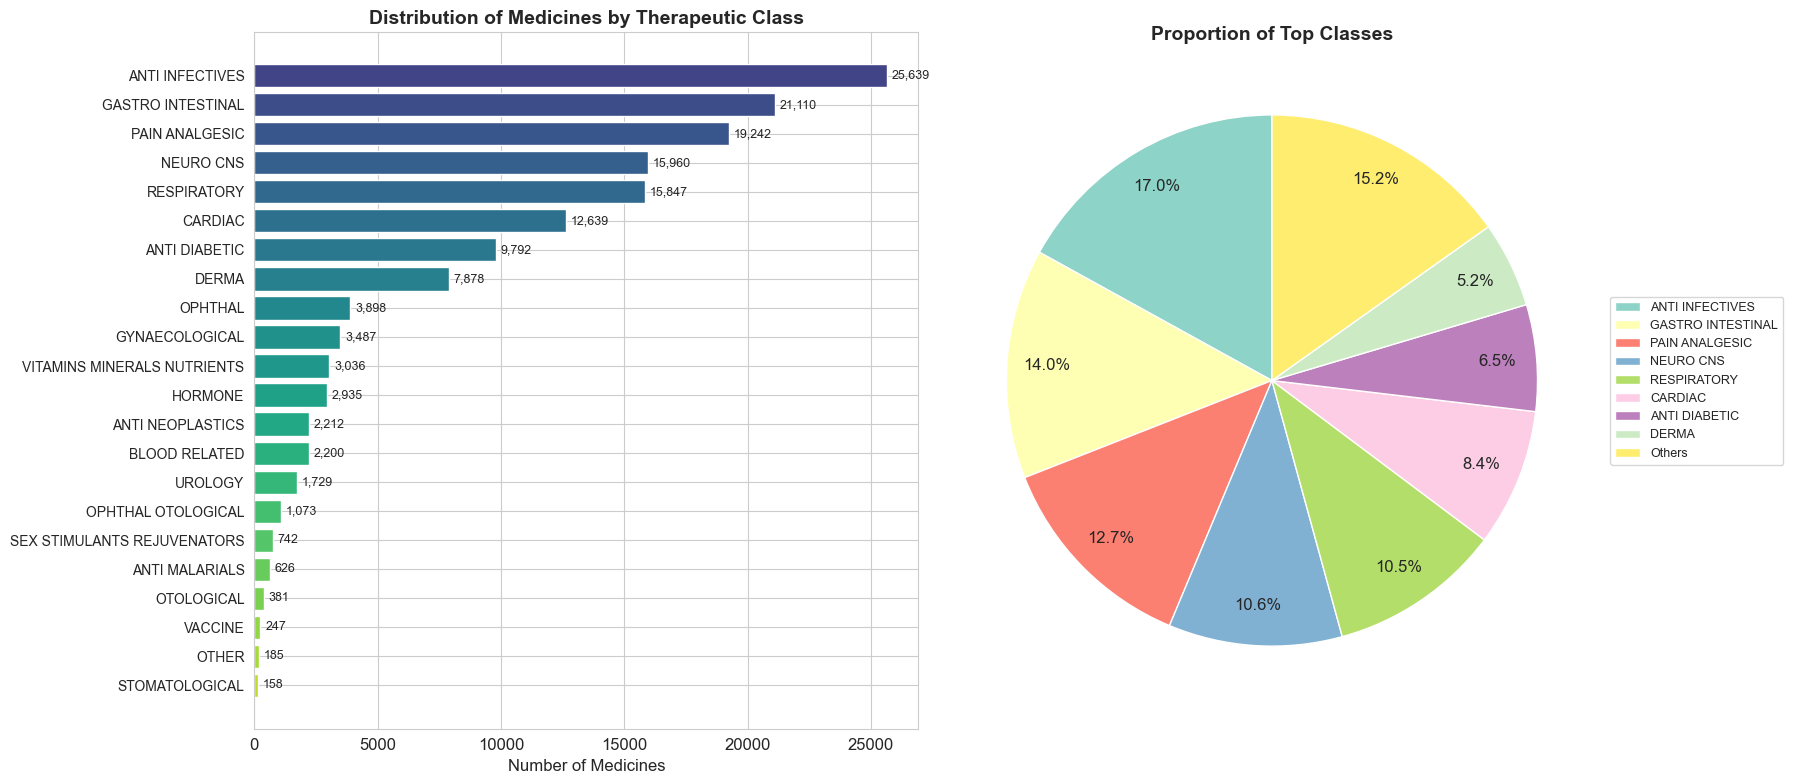


Class imbalance ratio: 25,639 (max) vs 158 (min) = 162x difference


In [21]:
# Class distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Bar chart
class_counts = df['Therapeutic_Class_Clean'].value_counts()
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(class_counts)))

ax1 = axes[0]
bars = ax1.barh(range(len(class_counts)), class_counts.values, color=colors)
ax1.set_yticks(range(len(class_counts)))
ax1.set_yticklabels(class_counts.index, fontsize=10)
ax1.set_xlabel('Number of Medicines', fontsize=12)
ax1.set_title('Distribution of Medicines by Therapeutic Class', fontsize=14, fontweight='bold')
ax1.invert_yaxis()

# Add count labels
for i, (count, bar) in enumerate(zip(class_counts.values, bars)):
    ax1.text(count + 200, i, f'{count:,}', va='center', fontsize=9)

# Pie chart for top classes
ax2 = axes[1]
top_n = 8
top_classes = class_counts.head(top_n)
other_count = class_counts.iloc[top_n:].sum()
pie_data = pd.concat([top_classes, pd.Series({'Others': other_count})])
pie_colors = plt.cm.Set3(np.linspace(0, 1, len(pie_data)))

wedges, texts, autotexts = ax2.pie(pie_data.values, labels=None, autopct='%1.1f%%',
                                     colors=pie_colors, pctdistance=0.85, startangle=90)
ax2.legend(pie_data.index, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
ax2.set_title('Proportion of Top Classes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClass imbalance ratio: {class_counts.max():,} (max) vs {class_counts.min():,} (min) = {class_counts.max()/class_counts.min():.0f}x difference")

### 4.2 Class Imbalance Analysis

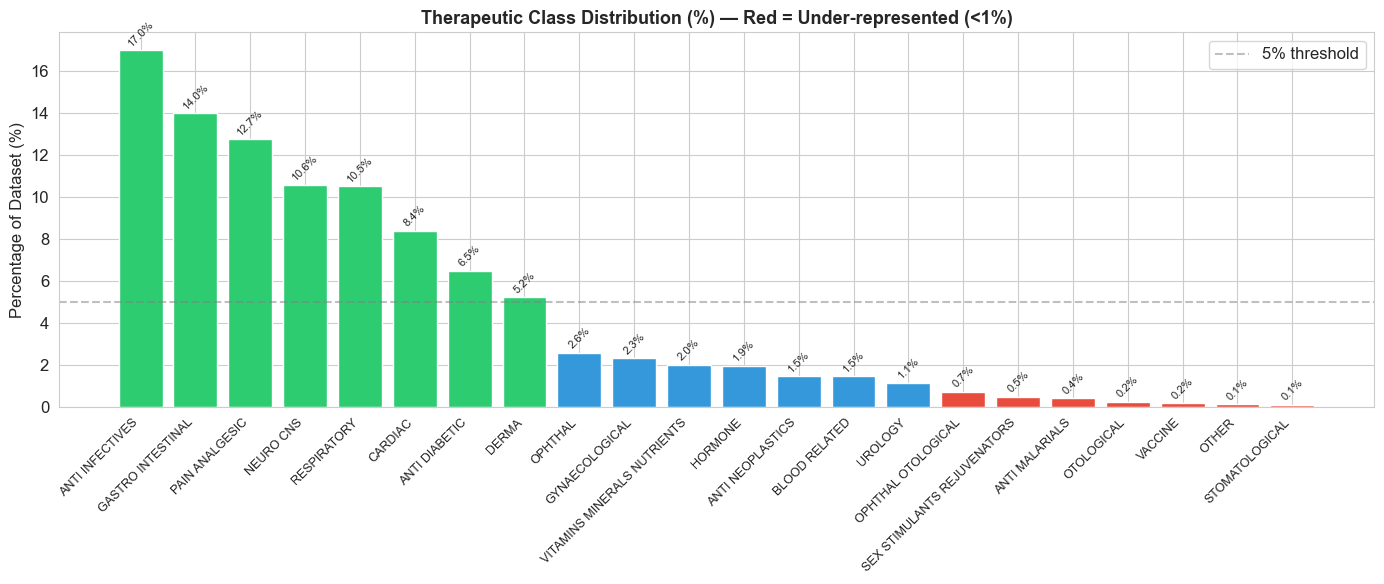

Under-represented classes (<1% of data): 7
  - OPHTHAL OTOLOGICAL: 0.71% (1,073 samples)
  - SEX STIMULANTS REJUVENATORS: 0.49% (742 samples)
  - ANTI MALARIALS: 0.41% (626 samples)
  - OTOLOGICAL: 0.25% (381 samples)
  - VACCINE: 0.16% (247 samples)
  - OTHER: 0.12% (185 samples)
  - STOMATOLOGICAL: 0.10% (158 samples)


In [22]:
# Detailed imbalance analysis
fig, ax = plt.subplots(figsize=(14, 6))

class_pct = (class_counts / class_counts.sum() * 100).round(2)
bars = ax.bar(range(len(class_pct)), class_pct.values, color=['#e74c3c' if p < 1 else '#3498db' if p < 5 else '#2ecc71' for p in class_pct.values])

ax.set_xticks(range(len(class_pct)))
ax.set_xticklabels(class_pct.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Percentage of Dataset (%)')
ax.set_title('Therapeutic Class Distribution (%) — Red = Under-represented (<1%)', fontsize=13, fontweight='bold')
ax.axhline(y=5, color='gray', linestyle='--', alpha=0.5, label='5% threshold')
ax.legend()

for i, pct in enumerate(class_pct.values):
    ax.text(i, pct + 0.2, f'{pct:.1f}%', ha='center', fontsize=8, rotation=45)

plt.tight_layout()
plt.savefig('02_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
under_rep = class_pct[class_pct < 1].index.tolist()
print(f"Under-represented classes (<1% of data): {len(under_rep)}")
for cls in under_rep:
    print(f"  - {cls}: {class_pct[cls]:.2f}% ({class_counts[cls]:,} samples)")
    

### 4.3 Text Length Analysis

Analyzing text columns: ['Contains', 'ProductIntroduction', 'ProductUses', 'ProductBenefits', 'SideEffect', 'HowToUse']


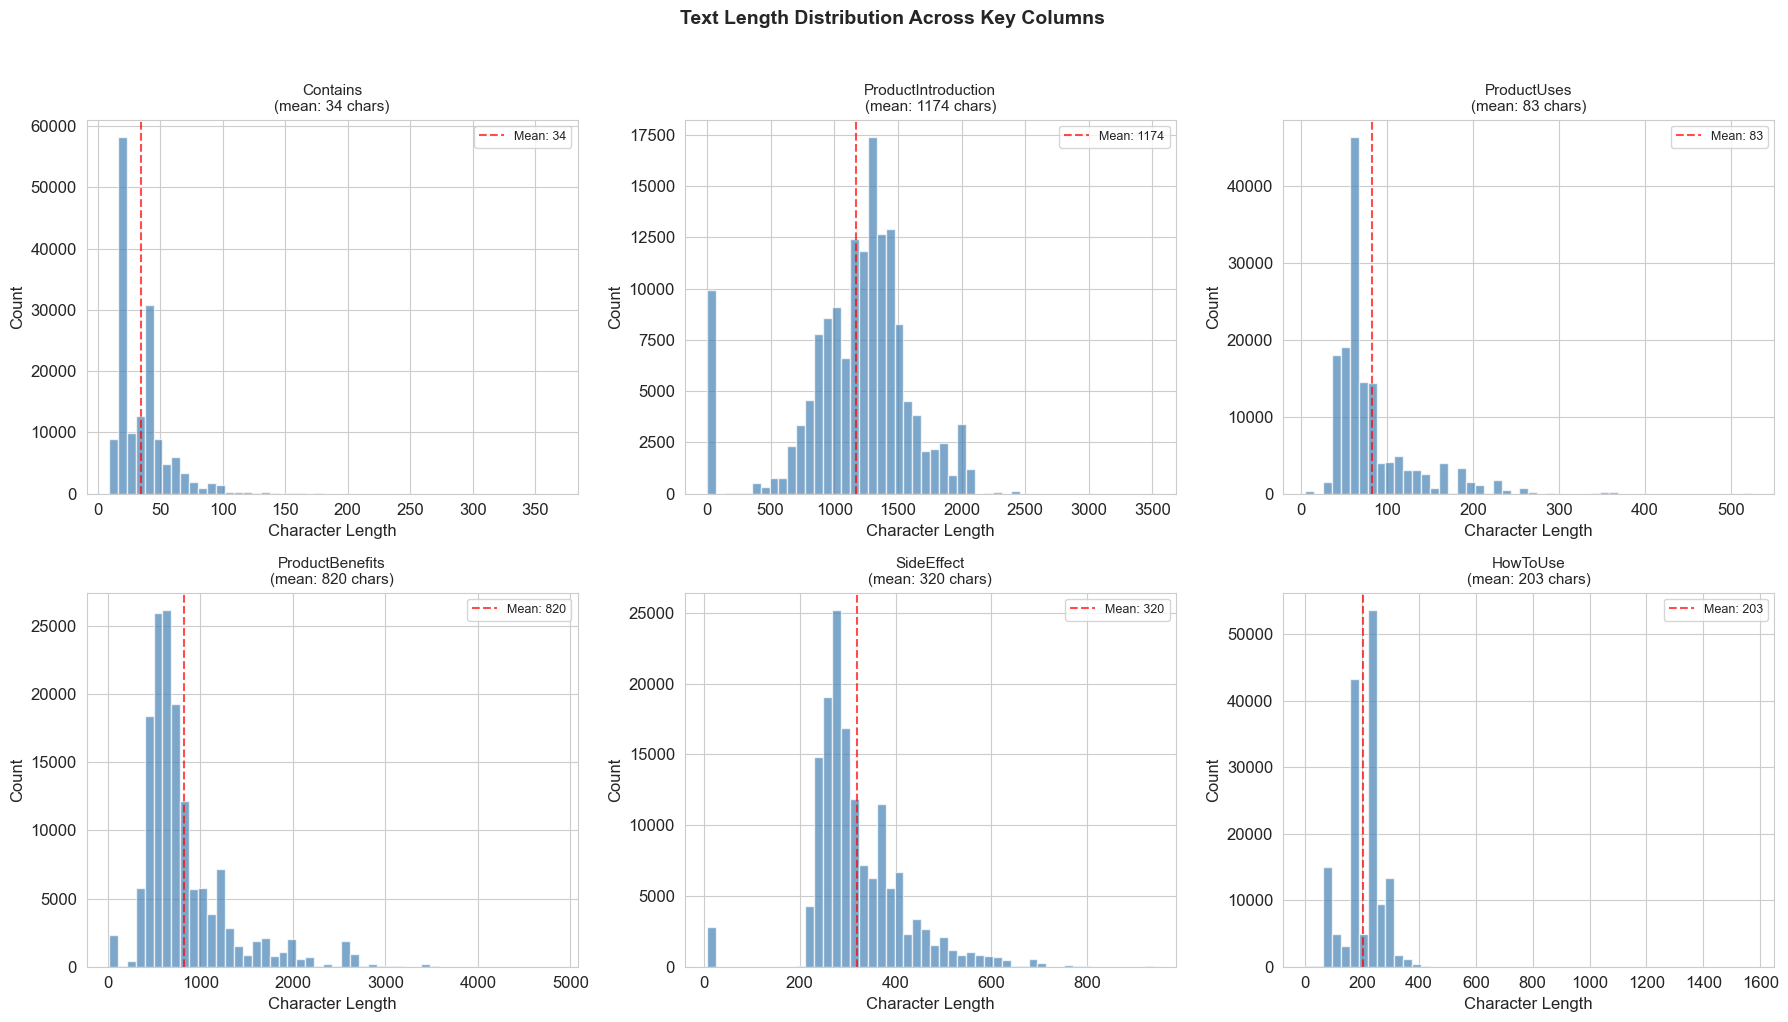

In [23]:
# Analyze text lengths across key columns
key_text_cols = [c for c in df.columns if any(kw in c.lower() for kw in ['use', 'benefit', 'effect', 'work', 'introduction', 'contains'])]
key_text_cols = key_text_cols[:6]  # Limit to 6 columns for the plot

print(f"Analyzing text columns: {key_text_cols}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_text_cols):
    if i >= 6:
        break
    lengths = df[col].astype(str).str.len()
    axes[i].hist(lengths, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
    axes[i].set_title(f'{col}\n(mean: {lengths.mean():.0f} chars)', fontsize=11)
    axes[i].set_xlabel('Character Length')
    axes[i].set_ylabel('Count')
    axes[i].axvline(lengths.mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {lengths.mean():.0f}')
    axes[i].legend(fontsize=9)

# Hide unused subplots
for j in range(i+1, 6):
    axes[j].set_visible(False)

plt.suptitle('Text Length Distribution Across Key Columns', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('03_text_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Word Clouds by Therapeutic Class

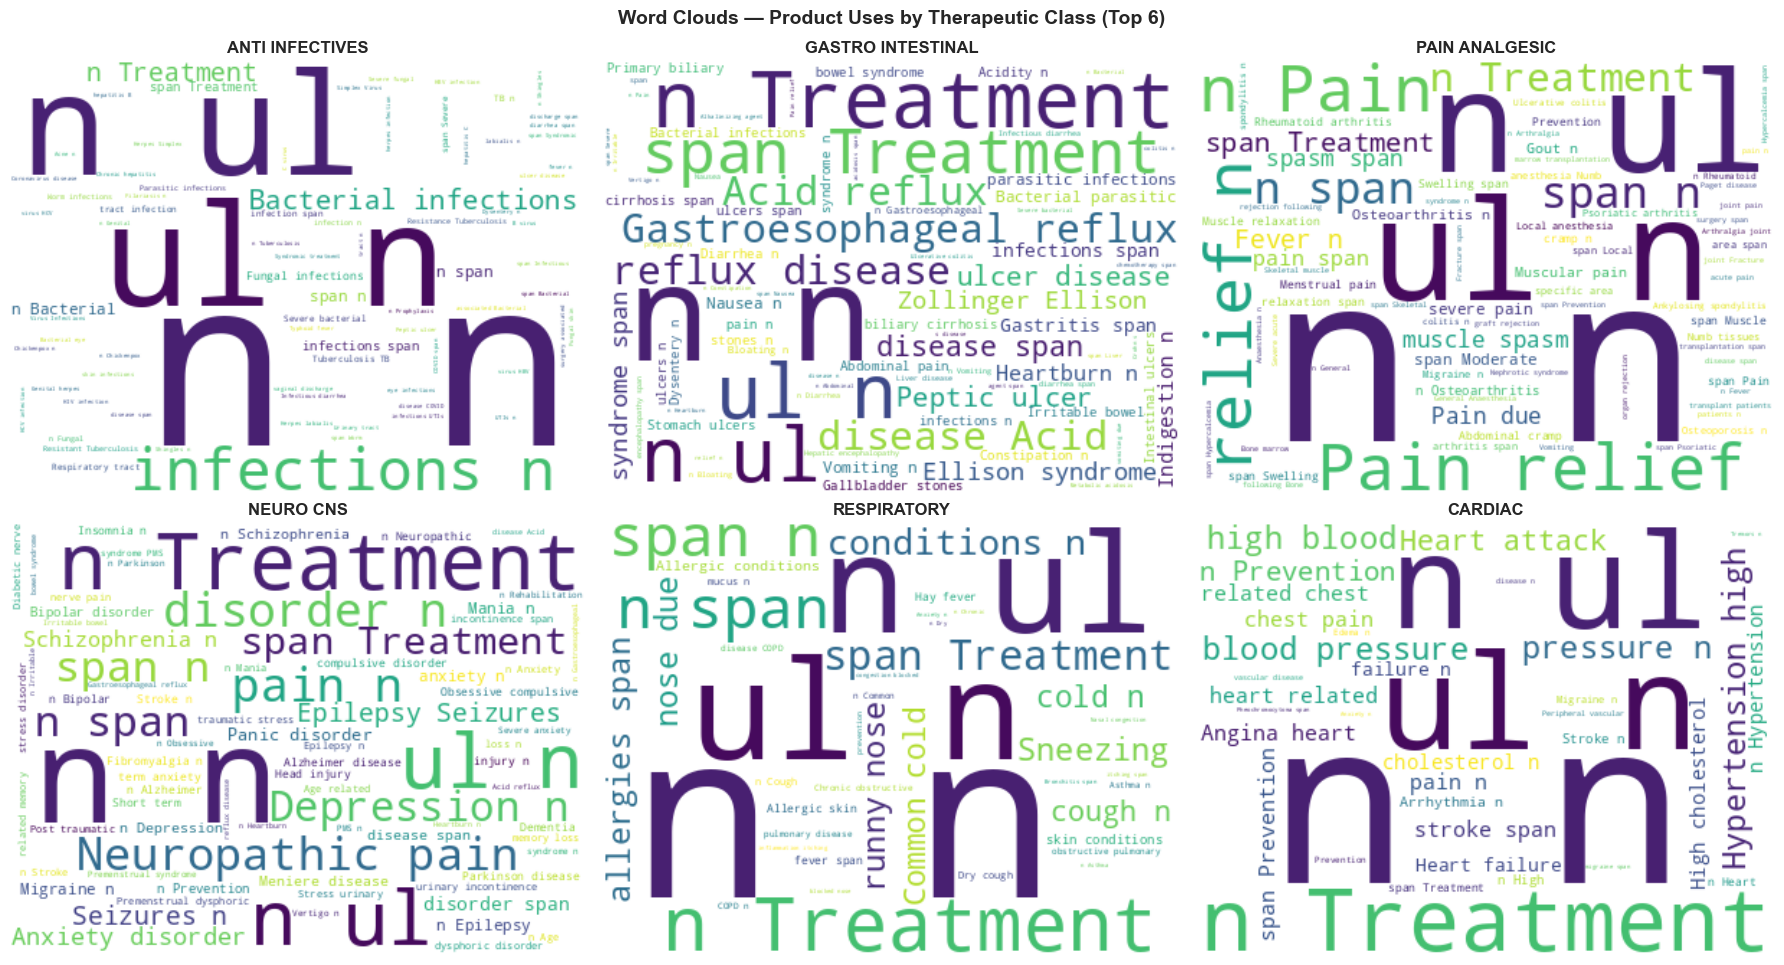

In [24]:
# Word clouds for top 6 therapeutic classes
top_6_classes = class_counts.head(6).index.tolist()
uses_col = [c for c in df.columns if 'use' in c.lower()][0]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, cls in enumerate(top_6_classes):
    text = ' '.join(df[df['Therapeutic_Class_Clean'] == cls][uses_col].astype(str).tolist())
    wc = WordCloud(width=400, height=300, background_color='white', 
                   max_words=80, colormap='viridis', random_state=42)
    wc.generate(text)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(cls, fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Word Clouds — Product Uses by Therapeutic Class (Top 6)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Top N-grams Analysis

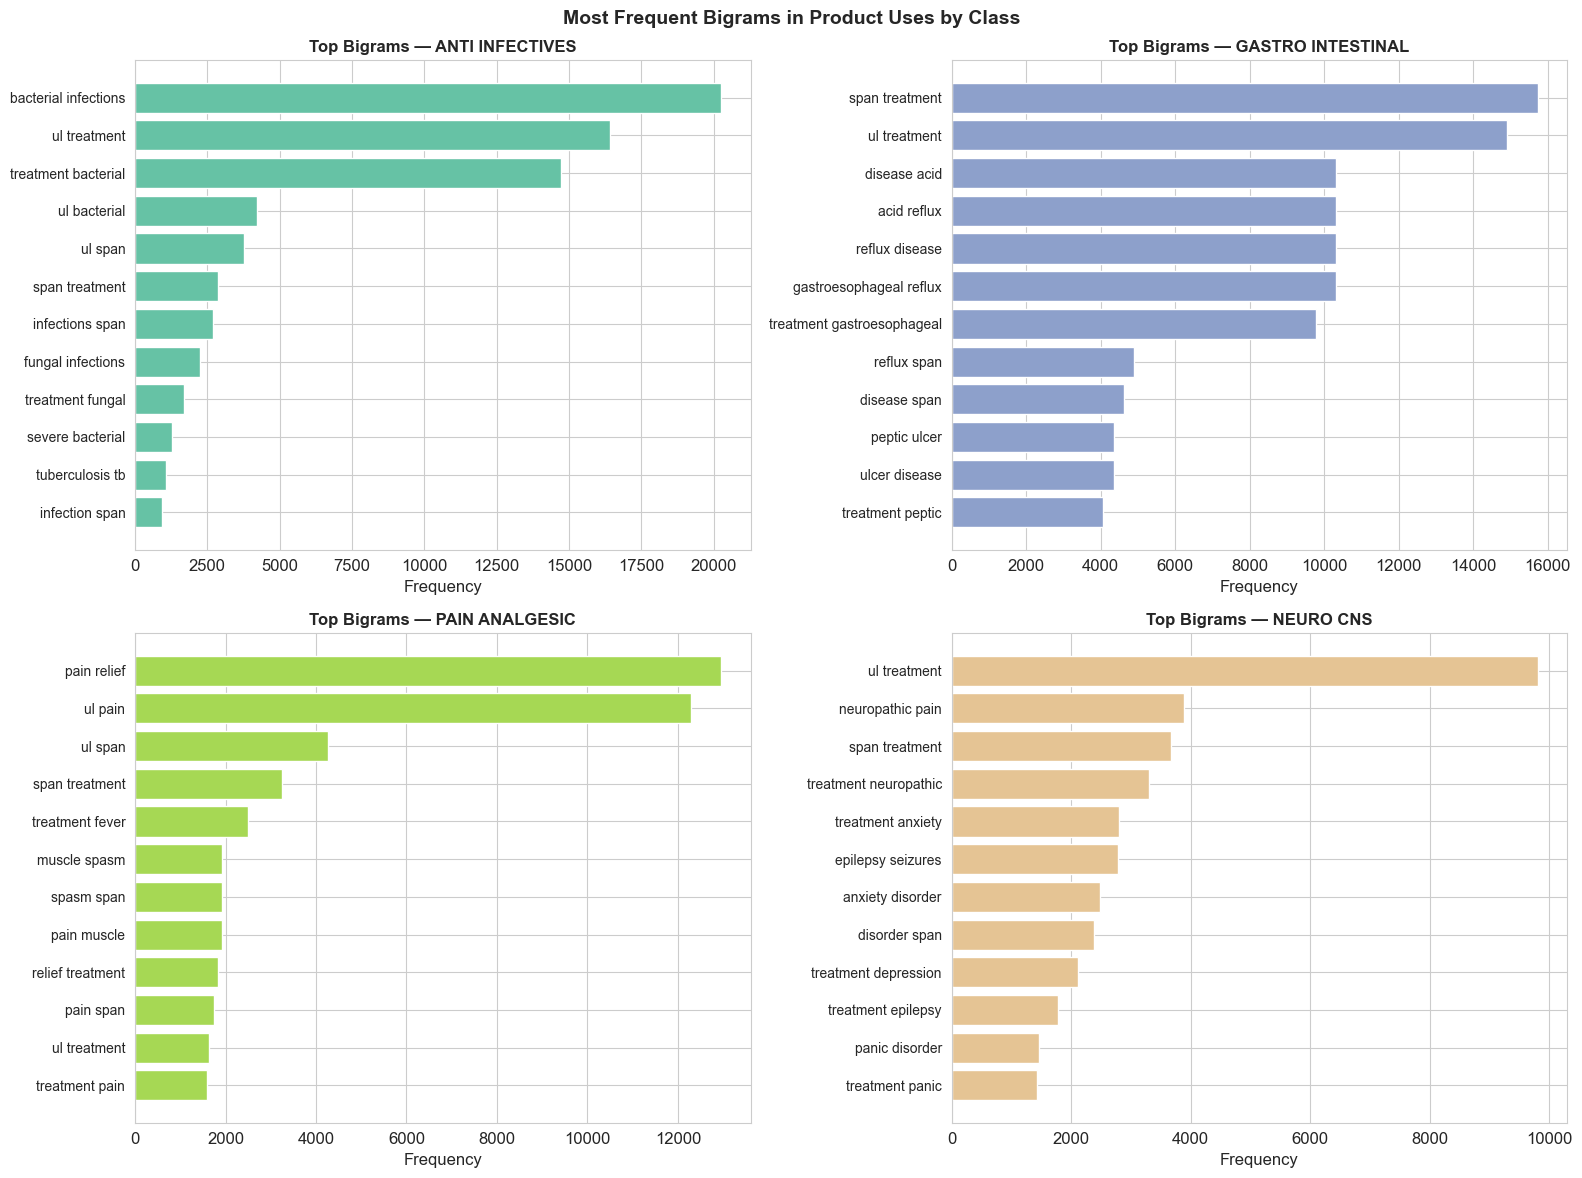

In [25]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=2, top_k=15):
    """Extract top n-grams from a text corpus."""
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=10000)
    ngrams = vec.fit_transform(corpus)
    count_values = ngrams.toarray().sum(axis=0)
    vocab = vec.get_feature_names_out()
    df_ngrams = pd.DataFrame({'ngram': vocab, 'count': count_values})
    return df_ngrams.sort_values('count', ascending=False).head(top_k)

# Top bigrams for the top 4 classes
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
top_4 = class_counts.head(4).index.tolist()

for i, cls in enumerate(top_4):
    class_text = df[df['Therapeutic_Class_Clean'] == cls][uses_col].astype(str).tolist()
    bigrams = get_top_ngrams(class_text, n=2, top_k=12)
    
    axes[i].barh(range(len(bigrams)), bigrams['count'].values, color=plt.cm.Set2(i/4))
    axes[i].set_yticks(range(len(bigrams)))
    axes[i].set_yticklabels(bigrams['ngram'].values, fontsize=10)
    axes[i].invert_yaxis()
    axes[i].set_title(f'Top Bigrams — {cls}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Frequency')

plt.suptitle('Most Frequent Bigrams in Product Uses by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_top_bigrams.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.6 Categorical Features Analysis

In [26]:
# Analyze categorical features
cat_cols = [c for c in df.columns if any(kw in c.lower() for kw in ['habit', 'chemical', 'action']) 
            and 'clean' not in c.lower()]

for col in cat_cols:
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(f"Unique values: {df[col].nunique()}")
    print(f"Top 10 values:")
    print(df[col].value_counts().head(10))


Column: Chemical_Class
Unique values: 870
Top 10 values:
Chemical_Class
Unknown                                                         71468
  Fluoroquinolone                                                3579
  Sulfinylbenzimidazole Derivative                               3205
  Broad Spectrum (Third & fourth generation cephalosporins)      2905
  Gluco/mineralocorticoids, progestogins and derivatives         1678
  Macrolides                                                     1624
  Glucocorticoids                                                1623
  Azole derivatives Imidazoles                                   1575
  Broad spectrum (Third & fourth generation cephalosporins       1385
  Carbazole Derivative                                           1225
Name: count, dtype: int64

Column: Habit_Forming
Unique values: 4
Top 10 values:
Habit_Forming
No     147505
Yes      3325
~         181
.           5
Name: count, dtype: int64

Column: Action_Class
Unique values: 406
Top 10 va

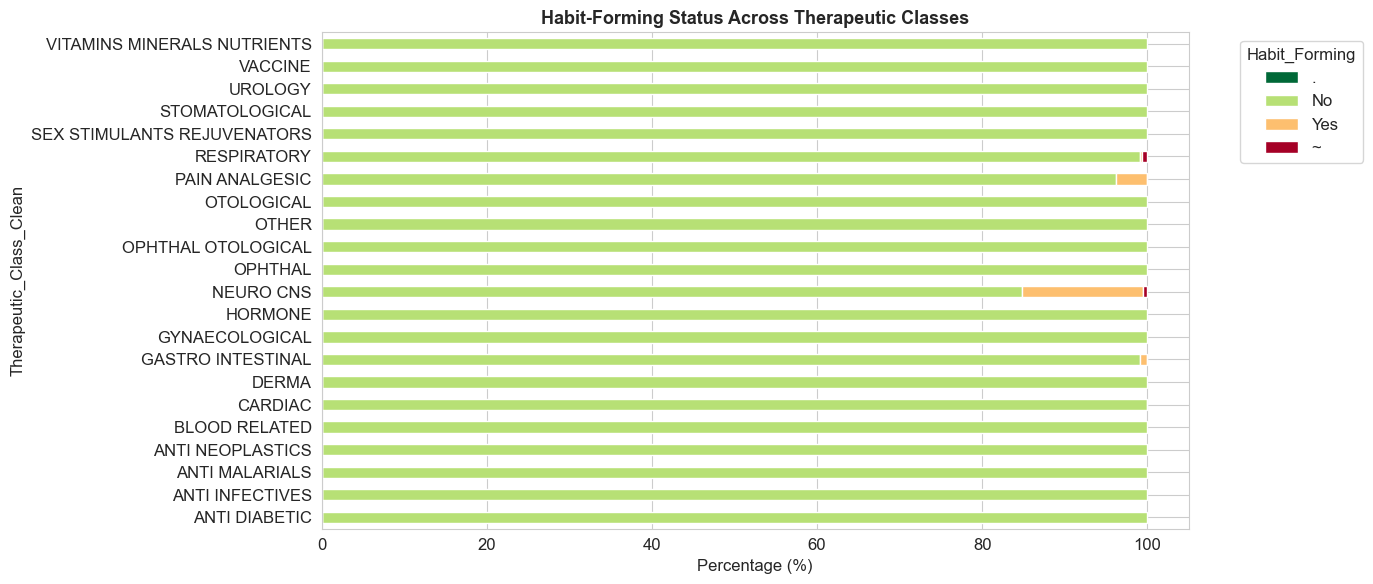

In [27]:
# Habit Forming distribution across therapeutic classes
habit_col = [c for c in df.columns if 'habit' in c.lower()][0]

fig, ax = plt.subplots(figsize=(14, 6))
habit_cross = pd.crosstab(df['Therapeutic_Class_Clean'], df[habit_col], normalize='index') * 100

habit_cross.plot(kind='barh', stacked=True, ax=ax, colormap='RdYlGn_r')
ax.set_xlabel('Percentage (%)')
ax.set_title('Habit-Forming Status Across Therapeutic Classes', fontsize=13, fontweight='bold')
ax.legend(title=habit_col, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('06_habit_forming.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.7 Correlation Between Categorical Features

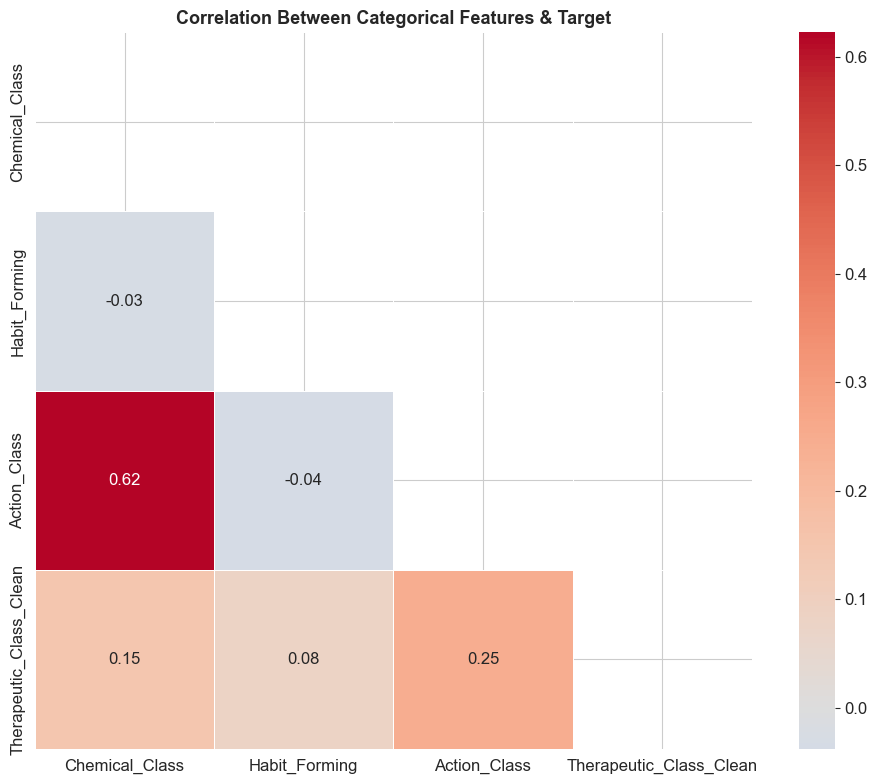

In [28]:
# Encode categoricals and check correlations
from sklearn.preprocessing import LabelEncoder

cat_encoded = pd.DataFrame()
le_dict = {}

for col in cat_cols + ['Therapeutic_Class_Clean']:
    le = LabelEncoder()
    cat_encoded[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

fig, ax = plt.subplots(figsize=(10, 8))
corr = cat_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Correlation Between Categorical Features & Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### EDA Summary

> **Key findings to note:**
> 1. The dataset shows significant class imbalance — the largest class is ~165x bigger than the smallest
> 2. Text columns like ProductUses and HowWorks contain the richest information for classification
> 3. Word clouds show clear differences in vocabulary across therapeutic classes (good signal for NLP)
> 4. Habit_Forming status varies significantly across classes (useful categorical feature)
> 5. Action_Class and Chemical_Class have moderate correlation with the target

---
## 5. Text Preprocessing (NLP Pipeline) <a id="5-text-preprocessing-nlp-pipeline"></a>

Since this is fundamentally a text classification problem, we need a proper NLP pipeline to convert raw text into clean, tokenized, lemmatized text.

In [29]:
# Initialize NLP tools
stop_words = set(stopwords.words('english'))
# Add domain-specific stopwords that appear everywhere
stop_words.update(['tablet', 'mg', 'used', 'treatment', 'medicine', 'doctor', 
                   'take', 'may', 'also', 'use', 'help', 'one', 'drug', 'capsule',
                   'injection', 'dose', 'patient', 'ml'])
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Full NLP preprocessing pipeline."""
    if pd.isna(text) or text == '':
        return ''
    text = str(text).lower()
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove special characters (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

# Test on a sample
sample_text = df[uses_col].iloc[0]
print("ORIGINAL:")
print(sample_text[:300])
print("\nPREPROCESSED:")
print(preprocess_text(sample_text)[:300])

ORIGINAL:
\n \n ul \"\" \n 0 \n Schizophrenia\n \n \n

PREPROCESSED:
schizophrenian


In [30]:
# Apply preprocessing to all key text columns
# We'll concatenate the most informative columns into a single text feature

# Identify key columns for concatenation
uses_col = [c for c in df.columns if 'use' in c.lower() and 'how' not in c.lower()][0]
works_col = [c for c in df.columns if 'work' in c.lower()][0]
contains_col = [c for c in df.columns if 'contains' in c.lower() or 'contain' in c.lower()][0]
benefits_col = [c for c in df.columns if 'benefit' in c.lower()][0]

print(f"Columns to concatenate:")
print(f"  1. {uses_col}")
print(f"  2. {works_col}")
print(f"  3. {contains_col}")
print(f"  4. {benefits_col}")

# Concatenate raw text first
print("\nConcatenating text columns...")
df['combined_text'] = (df[uses_col].astype(str) + ' ' + 
                        df[works_col].astype(str) + ' ' + 
                        df[contains_col].astype(str) + ' ' + 
                        df[benefits_col].astype(str))

# Apply preprocessing
print("Preprocessing combined text (this may take 5-10 minutes on 192K rows)...")
print("Processing... ", end='')

# Process in chunks for progress reporting
chunk_size = 20000
processed = []
for i in range(0, len(df), chunk_size):
    chunk = df['combined_text'].iloc[i:i+chunk_size].apply(preprocess_text)
    processed.append(chunk)
    print(f"{min(i+chunk_size, len(df)):,}/{len(df):,}... ", end='')

df['processed_text'] = pd.concat(processed)
print("\nDone!")

# Quick stats
avg_tokens = df['processed_text'].str.split().str.len().mean()
print(f"\nAverage tokens per document after preprocessing: {avg_tokens:.0f}")

Columns to concatenate:
  1. ProductUses
  2. HowWorks
  3. Contains
  4. ProductBenefits

Concatenating text columns...
Preprocessing combined text (this may take 5-10 minutes on 192K rows)...
Processing... 20,000/151,016... 40,000/151,016... 60,000/151,016... 80,000/151,016... 100,000/151,016... 120,000/151,016... 140,000/151,016... 151,016/151,016... 
Done!

Average tokens per document after preprocessing: 99


In [31]:
# Preview preprocessed text
print("Sample preprocessed text (first 3 rows):\n")
for i in range(3):
    cls = df['Therapeutic_Class_Clean'].iloc[i]
    text = df['processed_text'].iloc[i][:200]
    print(f"[{cls}] {text}...")
    print()

Sample preprocessed text (first 3 rows):

[NEURO CNS] schizophrenian andol typical antipsychotic work blocking action dopamine chemical messenger brain affect thought mood haloperidol schizophrenia schizophrenia mental disorder person thinking ability fe...

[ANTI NEOPLASTICS] cancer colon rectumn nonsmall cell lung cancern kidney cancern brain tumorn ovarian cancern cervical cancern avastin antiangiogenic medication work blocking protein called vascular endothelial growth ...

[BLOOD RELATED] anemia due chronic kidney diseasen anemia due cancer chemotherapyn actorise erythropoiesisstimulating agent esa work stimulating bone marrow soft tissue inside bone produce red blood cell produce red ...



---
## 6. Feature Engineering <a id="6-feature-engineering"></a>

We'll convert the preprocessed text into TF-IDF features and combine them with encoded categorical features.

### 6.1 TF-IDF Vectorization

In [32]:
# TF-IDF Vectorization
print("Fitting TF-IDF vectorizer...")

tfidf = TfidfVectorizer(
    max_features=15000,      # Limit to top 15K features for memory efficiency
    ngram_range=(1, 2),      # Unigrams + bigrams
    min_df=5,                # Must appear in at least 5 documents
    max_df=0.95,             # Ignore terms in >95% of documents
    sublinear_tf=True,       # Apply sublinear TF scaling (1 + log(tf))
    strip_accents='unicode'
)

X_tfidf = tfidf.fit_transform(df['processed_text'])

print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"  → {X_tfidf.shape[0]:,} documents × {X_tfidf.shape[1]:,} features")
print(f"  → Sparsity: {1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]):.4%}")

# Show top features
feature_names = tfidf.get_feature_names_out()
print(f"\nTop 20 TF-IDF features by average importance:")
avg_tfidf = X_tfidf.mean(axis=0).A1
top_idx = avg_tfidf.argsort()[-20:][::-1]
for i, idx in enumerate(top_idx, 1):
    print(f"  {i:2d}. {feature_names[idx]:30s} (avg TF-IDF: {avg_tfidf[idx]:.4f})")

Fitting TF-IDF vectorizer...
TF-IDF matrix shape: (151016, 15000)
  → 151,016 documents × 15,000 features
  → Sparsity: 99.0504%

Top 20 TF-IDF features by average importance:
   1. infection                      (avg TF-IDF: 0.0285)
   2. work                           (avg TF-IDF: 0.0250)
   3. pain                           (avg TF-IDF: 0.0247)
   4. bacteria                       (avg TF-IDF: 0.0231)
   5. bacterial                      (avg TF-IDF: 0.0221)
   6. make                           (avg TF-IDF: 0.0207)
   7. blood                          (avg TF-IDF: 0.0206)
   8. relief                         (avg TF-IDF: 0.0193)
   9. symptom                        (avg TF-IDF: 0.0193)
  10. feel                           (avg TF-IDF: 0.0187)
  11. medicine                       (avg TF-IDF: 0.0185)
  12. combination                    (avg TF-IDF: 0.0183)
  13. help                           (avg TF-IDF: 0.0182)
  14. better                         (avg TF-IDF: 0.0181)
  15. prescr

### 6.2 Encode Categorical Features

In [33]:
# Encode categorical features
from scipy.sparse import csr_matrix

# Identify available categorical columns
cat_features = []
for col in df.columns:
    if any(kw in col.lower() for kw in ['habit', 'chemical_class', 'action_class']) and 'clean' not in col.lower():
        cat_features.append(col)

print(f"Categorical features to encode: {cat_features}")

le_features = {}
encoded_cats = []

for col in cat_features:
    le = LabelEncoder()
    encoded = le.fit_transform(df[col].astype(str))
    encoded_cats.append(csr_matrix(encoded.reshape(-1, 1)))
    le_features[col] = le
    print(f"  {col}: {le.classes_.shape[0]} unique values")

# Combine TF-IDF + categorical features
if encoded_cats:
    X_combined = hstack([X_tfidf] + encoded_cats)
else:
    X_combined = X_tfidf
    
print(f"\nFinal feature matrix: {X_combined.shape}")
print(f"  → TF-IDF features: {X_tfidf.shape[1]:,}")
print(f"  → Categorical features: {len(cat_features)}")
print(f"  → Total features: {X_combined.shape[1]:,}")

Categorical features to encode: ['Chemical_Class', 'Habit_Forming', 'Action_Class']
  Chemical_Class: 870 unique values
  Habit_Forming: 4 unique values
  Action_Class: 406 unique values

Final feature matrix: (151016, 15003)
  → TF-IDF features: 15,000
  → Categorical features: 3
  → Total features: 15,003


### 6.3 Encode Target & Train-Test Split

In [34]:
# Encode target variable
le_target = LabelEncoder()
y = le_target.fit_transform(df['Therapeutic_Class_Clean'])

print(f"Target classes ({len(le_target.classes_)}):")
for i, cls in enumerate(le_target.classes_):
    count = (y == i).sum()
    print(f"  {i:2d} → {cls} ({count:,} samples)")

# Stratified train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Crucial for imbalanced classes
)

print(f"\nTrain set: {X_train.shape[0]:,} samples")
print(f"Test set:  {X_test.shape[0]:,} samples")

# Verify stratification
print(f"\nStratification check (class proportions):")
train_props = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_props = pd.Series(y_test).value_counts(normalize=True).sort_index()
for i in range(len(le_target.classes_)):
    print(f"  {le_target.classes_[i]:35s}: Train={train_props[i]*100:.2f}%  Test={test_props[i]*100:.2f}%")

Target classes (22):
   0 → ANTI DIABETIC (9,792 samples)
   1 → ANTI INFECTIVES (25,639 samples)
   2 → ANTI MALARIALS (626 samples)
   3 → ANTI NEOPLASTICS (2,212 samples)
   4 → BLOOD RELATED (2,200 samples)
   5 → CARDIAC (12,639 samples)
   6 → DERMA (7,878 samples)
   7 → GASTRO INTESTINAL (21,110 samples)
   8 → GYNAECOLOGICAL (3,487 samples)
   9 → HORMONE (2,935 samples)
  10 → NEURO CNS (15,960 samples)
  11 → OPHTHAL (3,898 samples)
  12 → OPHTHAL OTOLOGICAL (1,073 samples)
  13 → OTHER (185 samples)
  14 → OTOLOGICAL (381 samples)
  15 → PAIN ANALGESIC (19,242 samples)
  16 → RESPIRATORY (15,847 samples)
  17 → SEX STIMULANTS REJUVENATORS (742 samples)
  18 → STOMATOLOGICAL (158 samples)
  19 → UROLOGY (1,729 samples)
  20 → VACCINE (247 samples)
  21 → VITAMINS MINERALS NUTRIENTS (3,036 samples)

Train set: 120,812 samples
Test set:  30,204 samples

Stratification check (class proportions):
  ANTI DIABETIC                      : Train=6.48%  Test=6.48%
  ANTI INFECTIVES   

---
## 7. Model Training & Comparison <a id="7-model-training--comparison"></a>


In [35]:
# 7. Model Training & Comparison
results = {}
import time

def train_and_evaluate(name, model, use_tfidf_only=False):
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")
    start = time.time()
    
    if use_tfidf_only:
        model.fit(X_train[:, :X_tfidf.shape[1]], y_train)
        y_pred = model.predict(X_test[:, :X_tfidf.shape[1]])
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    elapsed = time.time() - start
    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average='weighted')
    f1_m = f1_score(y_test, y_pred, average='macro')
    prec_w = precision_score(y_test, y_pred, average='weighted')
    rec_w = recall_score(y_test, y_pred, average='weighted')
    
    results[name] = {
        'Accuracy': acc, 'Weighted F1': f1_w, 'Macro F1': f1_m,
        'Weighted Precision': prec_w, 'Weighted Recall': rec_w,
        'Training Time (s)': elapsed, 'y_pred': y_pred
    }
    print(f"  Accuracy:          {acc:.4f}")
    print(f"  Weighted F1-Score: {f1_w:.4f}")
    print(f"  Macro F1-Score:    {f1_m:.4f}")
    print(f"  Training Time:     {elapsed:.1f}s")

print("Ready! Run each model below.")

Ready! Run each model below.


In [36]:
train_and_evaluate('Multinomial Naive Bayes', MultinomialNB(alpha=0.1), use_tfidf_only=True)


Training: Multinomial Naive Bayes
  Accuracy:          0.9693
  Weighted F1-Score: 0.9699
  Macro F1-Score:    0.9230
  Training Time:     0.7s


In [37]:
train_and_evaluate('Logistic Regression', LogisticRegression(
    max_iter=1000, class_weight='balanced', solver='lbfgs', random_state=42, C=1.0))


Training: Logistic Regression
  Accuracy:          0.8794
  Weighted F1-Score: 0.8904
  Macro F1-Score:    0.8106
  Training Time:     591.8s


In [38]:
train_and_evaluate('Random Forest', RandomForestClassifier(
    n_estimators=100, max_depth=50, max_features='sqrt',
    class_weight='balanced', random_state=42, n_jobs=-1))


Training: Random Forest
  Accuracy:          0.9977
  Weighted F1-Score: 0.9977
  Macro F1-Score:    0.9912
  Training Time:     34.0s


In [39]:
# Store actual model objects (needed for cross-validation & feature importance later)
models = {
    'Multinomial Naive Bayes': MultinomialNB(alpha=0.1).fit(X_train[:, :X_tfidf.shape[1]], y_train),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', solver='lbfgs', random_state=42, C=1.0).fit(X_train, y_train),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=50, max_features='sqrt',
        class_weight='balanced', random_state=42, n_jobs=-1).fit(X_train, y_train)
}
print(f"All {len(models)} model objects stored for evaluation phase.")

All 3 model objects stored for evaluation phase.


In [40]:
# Model comparison table
comparison_df = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k != 'y_pred'}
    for name, metrics in results.items()
}).T.round(4)

comparison_df = comparison_df.sort_values('Weighted F1', ascending=False)
print("\n" + "="*70)
print("MODEL COMPARISON (sorted by Weighted F1-Score)")
print("="*70)
print(comparison_df.to_string())

best_model_name = comparison_df.index[0]
print(f"\n★ Best Model: {best_model_name}")
print(f"  Weighted F1: {comparison_df.loc[best_model_name, 'Weighted F1']:.4f}")
print(f"  Accuracy:    {comparison_df.loc[best_model_name, 'Accuracy']:.4f}")


MODEL COMPARISON (sorted by Weighted F1-Score)
                         Accuracy  Weighted F1  Macro F1  Weighted Precision  Weighted Recall  Training Time (s)
Random Forest              0.9977       0.9977    0.9912              0.9977           0.9977            33.9958
Multinomial Naive Bayes    0.9693       0.9699    0.9230              0.9713           0.9693             0.7182
Logistic Regression        0.8794       0.8904    0.8106              0.9111           0.8794           591.8112

★ Best Model: Random Forest
  Weighted F1: 0.9977
  Accuracy:    0.9977


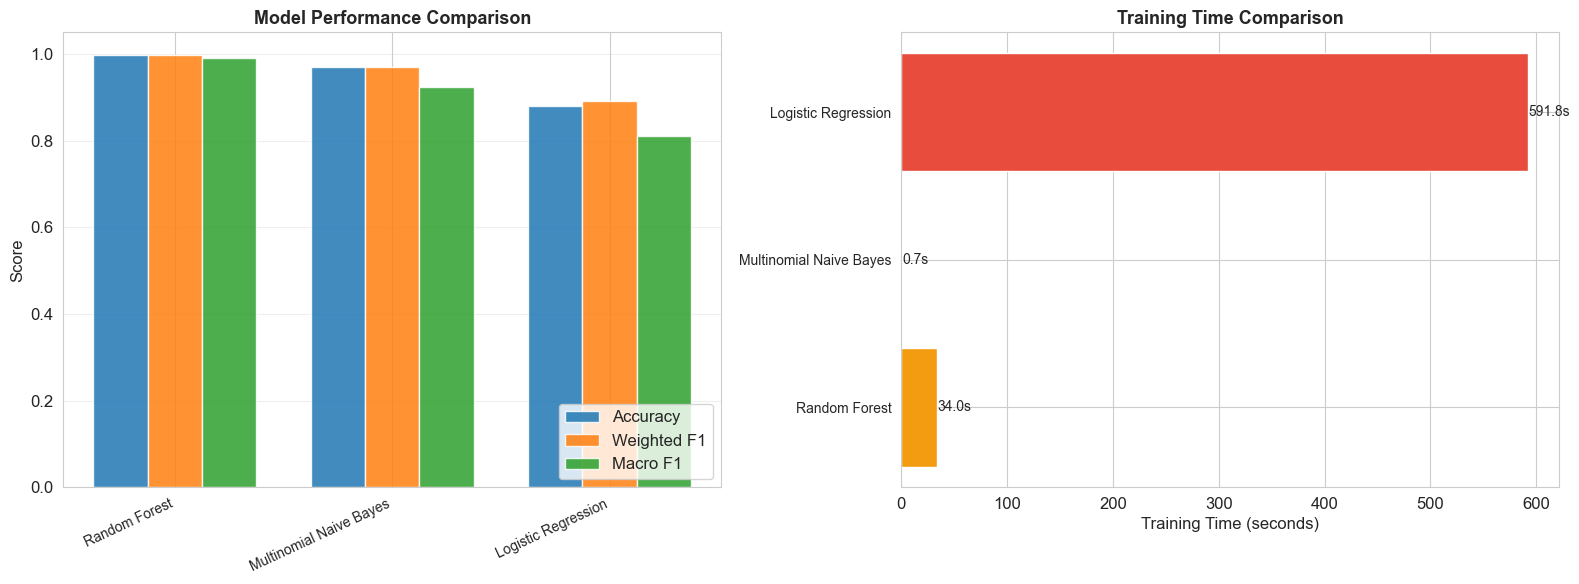

In [41]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
metrics_to_plot = ['Accuracy', 'Weighted F1', 'Macro F1']
comp_data = comparison_df[metrics_to_plot]
x = np.arange(len(comp_data))
width = 0.25

for i, metric in enumerate(metrics_to_plot):
    axes[0].bar(x + i*width, comp_data[metric], width, label=metric, alpha=0.85)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(comp_data.index, rotation=25, ha='right', fontsize=10)
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis='y', alpha=0.3)

# Training time
times = comparison_df['Training Time (s)']
colors = ['#2ecc71' if t < 30 else '#f39c12' if t < 120 else '#e74c3c' for t in times]
axes[1].barh(range(len(times)), times.values, color=colors)
axes[1].set_yticks(range(len(times)))
axes[1].set_yticklabels(times.index, fontsize=10)
axes[1].set_xlabel('Training Time (seconds)')
axes[1].set_title('Training Time Comparison', fontsize=13, fontweight='bold')
for i, t in enumerate(times.values):
    axes[1].text(t + 0.5, i, f'{t:.1f}s', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Model Evaluation & Deep Analysis <a id="8-model-evaluation--deep-analysis"></a>

### 8.1 Confusion Matrix (Best Model)

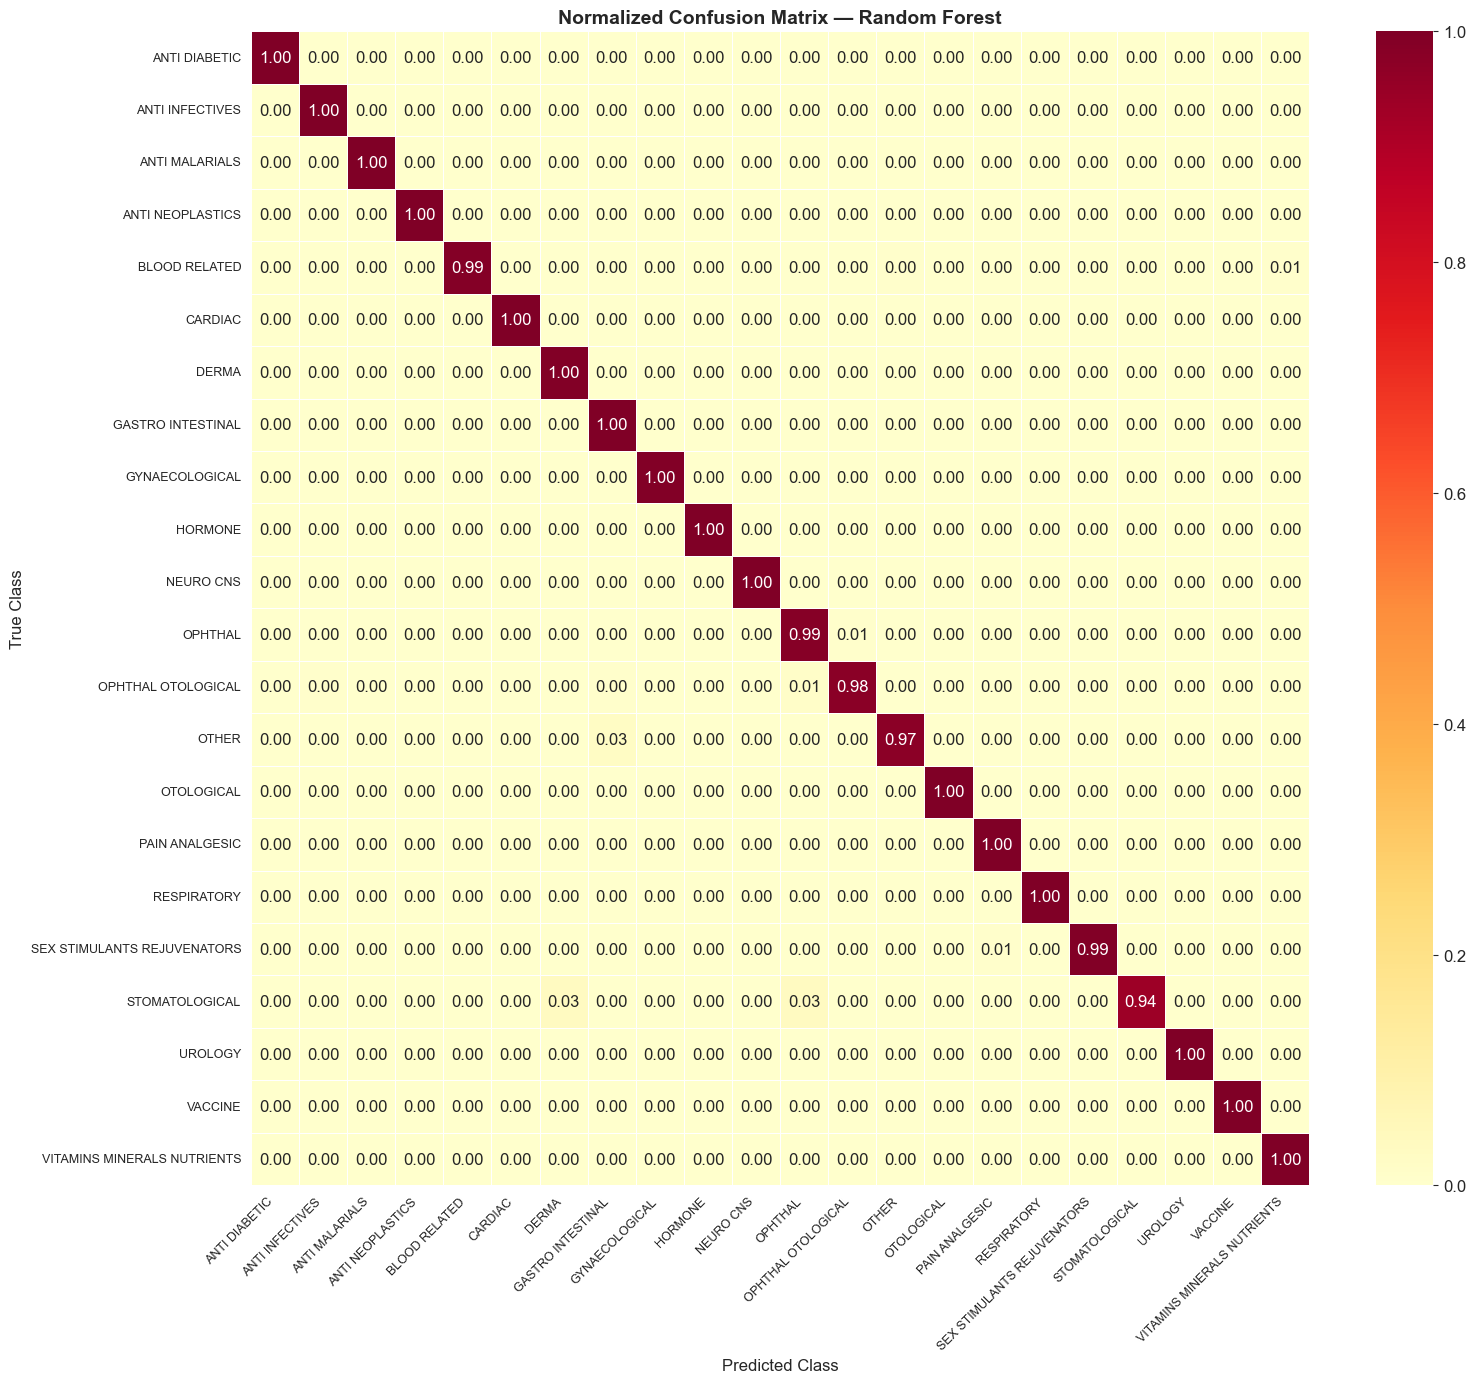

In [42]:
# Confusion matrix for the best model
best_preds = results[best_model_name]['y_pred']

fig, ax = plt.subplots(figsize=(16, 14))
cm = confusion_matrix(y_test, best_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_,
            ax=ax, linewidths=0.5, vmin=0, vmax=1)
ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_ylabel('True Class', fontsize=12)
ax.set_title(f'Normalized Confusion Matrix — {best_model_name}', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('09_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 Per-Class Classification Report

In [43]:
# Detailed classification report
print(f"\nClassification Report — {best_model_name}")
print("="*80)
report = classification_report(y_test, best_preds, target_names=le_target.classes_, output_dict=True)
report_df = pd.DataFrame(report).T

# Display the per-class metrics nicely
per_class = report_df.iloc[:-3]  # Exclude accuracy, macro avg, weighted avg
per_class = per_class.sort_values('f1-score', ascending=False)
print(per_class.round(4).to_string())

print(f"\n{'='*60}")
print(f"Overall Metrics:")
print(f"  Accuracy:      {report_df.loc['accuracy', 'precision']:.4f}")
print(f"  Macro Avg F1:  {report_df.loc['macro avg', 'f1-score']:.4f}")
print(f"  Weighted F1:   {report_df.loc['weighted avg', 'f1-score']:.4f}")


Classification Report — Random Forest
                             precision  recall  f1-score  support
OTOLOGICAL                      1.0000  1.0000    1.0000     76.0
VACCINE                         1.0000  1.0000    1.0000     49.0
UROLOGY                         1.0000  1.0000    1.0000    346.0
ANTI DIABETIC                   1.0000  0.9995    0.9997   1958.0
NEURO CNS                       0.9997  0.9994    0.9995   3192.0
RESPIRATORY                     0.9994  0.9991    0.9992   3170.0
HORMONE                         1.0000  0.9983    0.9991    587.0
CARDIAC                         0.9996  0.9984    0.9990   2528.0
PAIN ANALGESIC                  0.9990  0.9984    0.9987   3849.0
ANTI INFECTIVES                 0.9988  0.9980    0.9984   5128.0
GASTRO INTESTINAL               0.9962  0.9986    0.9974   4222.0
ANTI NEOPLASTICS                0.9955  0.9977    0.9966    442.0
SEX STIMULANTS REJUVENATORS     1.0000  0.9932    0.9966    148.0
ANTI MALARIALS                  0.992

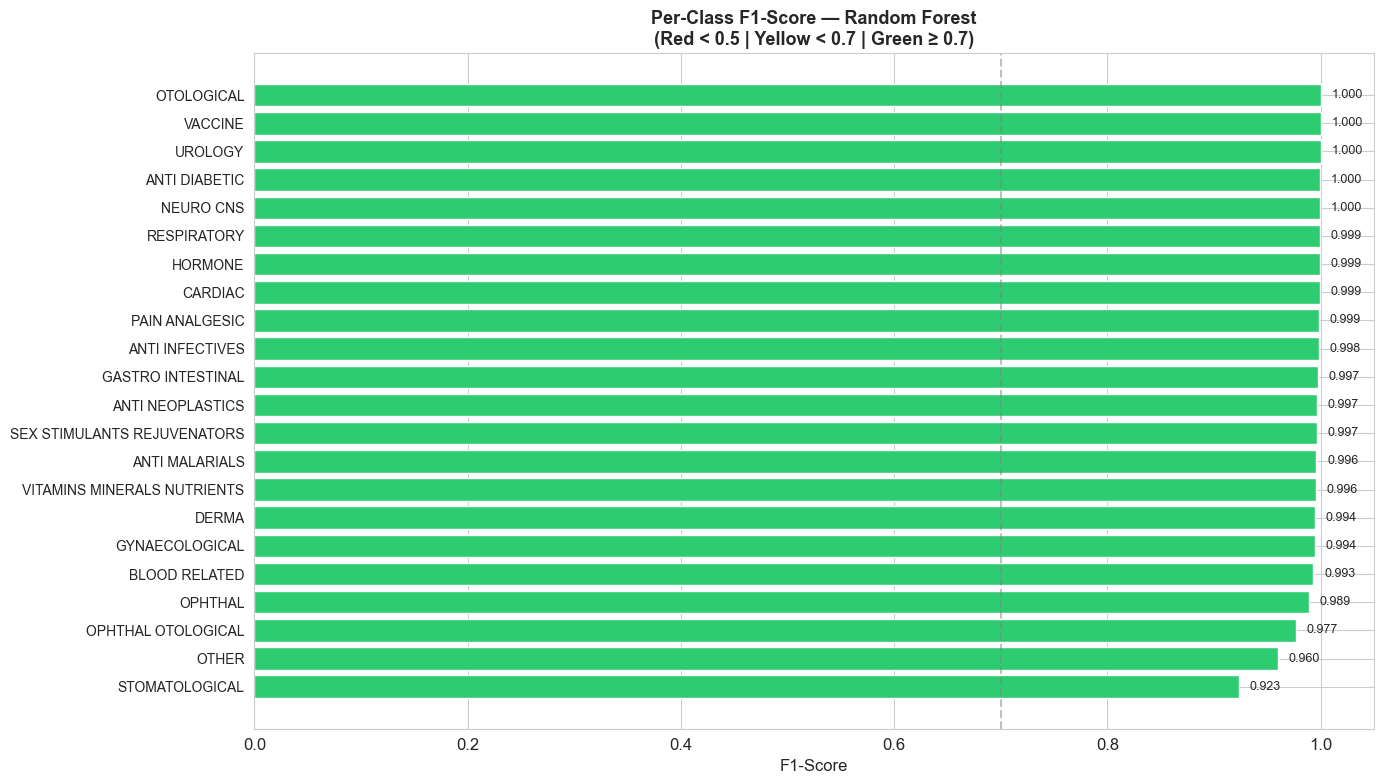

In [44]:
# Per-class F1-score visualization
fig, ax = plt.subplots(figsize=(14, 8))

f1_scores = per_class['f1-score'].sort_values(ascending=True)
colors = ['#e74c3c' if f < 0.5 else '#f39c12' if f < 0.7 else '#2ecc71' for f in f1_scores.values]

bars = ax.barh(range(len(f1_scores)), f1_scores.values, color=colors)
ax.set_yticks(range(len(f1_scores)))
ax.set_yticklabels(f1_scores.index, fontsize=10)
ax.set_xlabel('F1-Score', fontsize=12)
ax.set_title(f'Per-Class F1-Score — {best_model_name}\n(Red < 0.5 | Yellow < 0.7 | Green ≥ 0.7)', fontsize=13, fontweight='bold')
ax.axvline(x=0.7, color='gray', linestyle='--', alpha=0.5)

for i, score in enumerate(f1_scores.values):
    ax.text(score + 0.01, i, f'{score:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('10_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

# Identify weak classes
weak = f1_scores[f1_scores < 0.5]
if len(weak) > 0:
    print(f"\nWeak classes (F1 < 0.5): {len(weak)}")
    for cls, score in weak.items():
        print(f"  - {cls}: F1={score:.3f}")

### 8.3 Stratified K-Fold Cross-Validation

Running 5-Fold Stratified Cross-Validation for: Random Forest
This may take several minutes...

Cross-Validation Results (Weighted F1):
  Fold scores: ['0.9973', '0.9975', '0.9971', '0.9980', '0.9974']
  Mean:  0.9975
  Std:   0.0003
  Range: [0.9971, 0.9980]


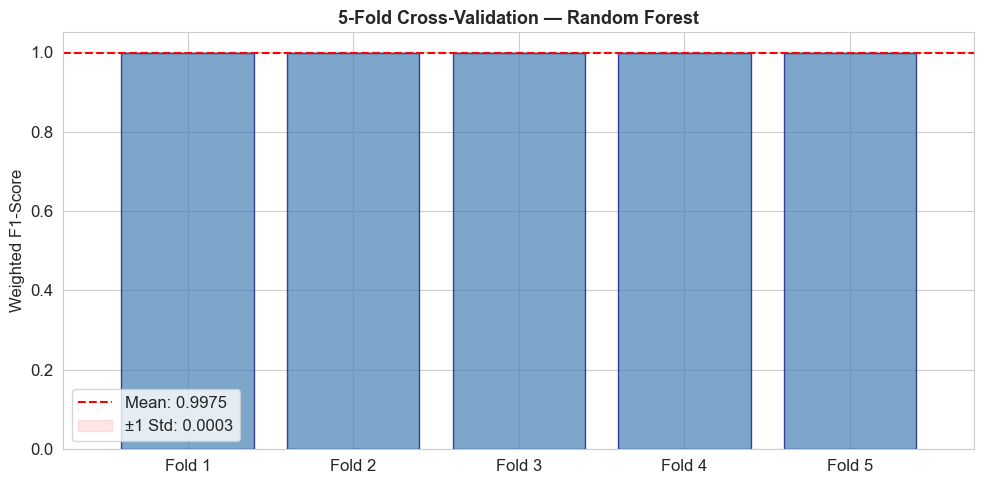

In [45]:
# 5-Fold Stratified Cross-Validation on the best model
print(f"Running 5-Fold Stratified Cross-Validation for: {best_model_name}")
print("This may take several minutes...\n")

best_model = models[best_model_name]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use appropriate features for the model
if 'Naive Bayes' in best_model_name:
    X_cv = X_combined[:, :X_tfidf.shape[1]]
else:
    X_cv = X_combined

cv_scores = cross_val_score(best_model, X_cv, y, cv=skf, scoring='f1_weighted', n_jobs=-1)

print(f"Cross-Validation Results (Weighted F1):")
print(f"  Fold scores: {[f'{s:.4f}' for s in cv_scores]}")
print(f"  Mean:  {cv_scores.mean():.4f}")
print(f"  Std:   {cv_scores.std():.4f}")
print(f"  Range: [{cv_scores.min():.4f}, {cv_scores.max():.4f}]")

# Visualize CV results
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.7, edgecolor='navy')
ax.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
ax.fill_between([0.5, 5.5], cv_scores.mean() - cv_scores.std(), cv_scores.mean() + cv_scores.std(),
                alpha=0.1, color='red', label=f'±1 Std: {cv_scores.std():.4f}')
ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax.set_ylabel('Weighted F1-Score')
ax.set_title(f'5-Fold Cross-Validation — {best_model_name}', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('11_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.4 Feature Importance Analysis

Analyzing feature importance for: Random Forest



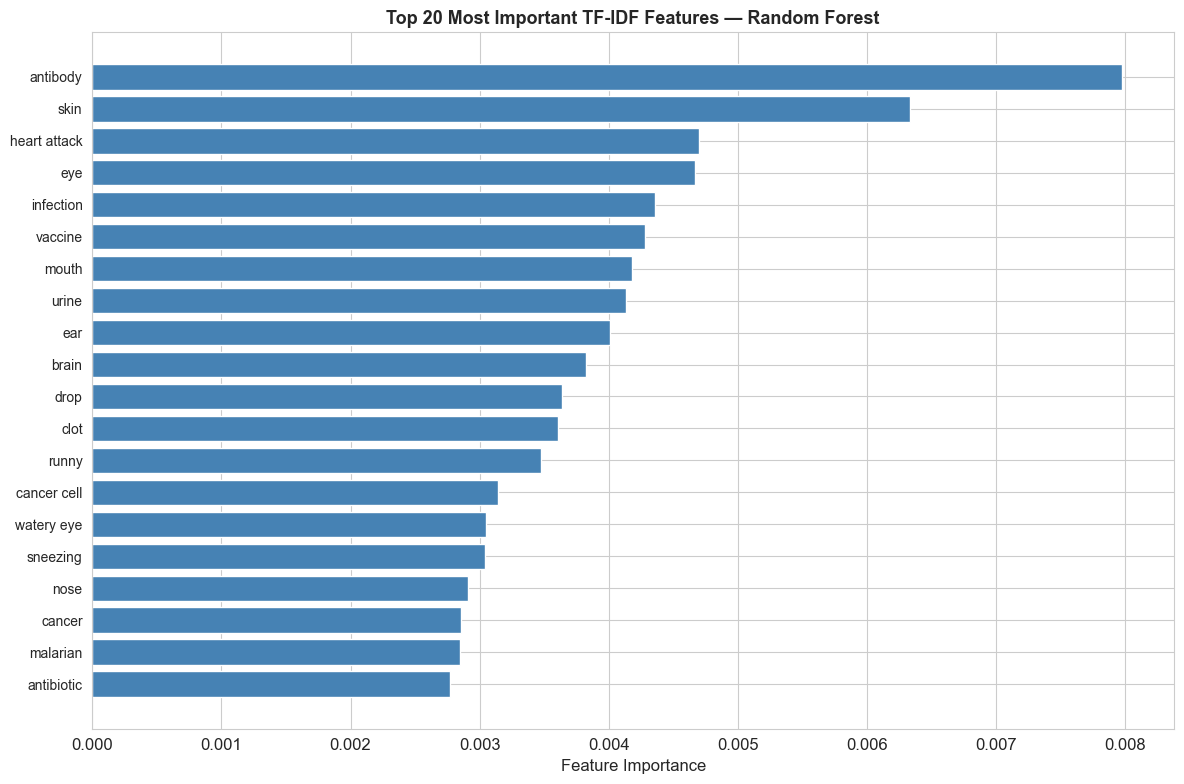

In [46]:
# Feature importance (method depends on model type)
print(f"Analyzing feature importance for: {best_model_name}\n")

if hasattr(models[best_model_name], 'coef_'):
    # For linear models (LR, SVM, NB)
    # Show most important features per class (top 3 classes)
    coef = models[best_model_name].coef_
    top_3_classes = class_counts.head(3).index.tolist()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for i, cls in enumerate(top_3_classes):
        cls_idx = list(le_target.classes_).index(cls)
        if coef.shape[0] > 1:
            importances = coef[cls_idx]
        else:
            importances = coef[0]
        
        # Only look at TF-IDF features
        tfidf_importances = importances[:len(feature_names)]
        top_15_idx = np.argsort(tfidf_importances)[-15:]
        
        axes[i].barh(range(15), tfidf_importances[top_15_idx], color=plt.cm.Set2(i/3))
        axes[i].set_yticks(range(15))
        axes[i].set_yticklabels([feature_names[j] for j in top_15_idx], fontsize=9)
        axes[i].set_title(f'{cls}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Coefficient Weight')
    
    plt.suptitle('Top 15 Most Important Features by Class', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('12_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

elif hasattr(models[best_model_name], 'feature_importances_'):
    # For tree-based models (RF, XGBoost)
    importances = models[best_model_name].feature_importances_
    tfidf_importances = importances[:len(feature_names)]
    top_20_idx = np.argsort(tfidf_importances)[-20:]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(range(20), tfidf_importances[top_20_idx], color='steelblue')
    ax.set_yticks(range(20))
    ax.set_yticklabels([feature_names[j] for j in top_20_idx], fontsize=10)
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top 20 Most Important TF-IDF Features — {best_model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('12_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

### 8.5 Error Analysis

Top 15 Most Common Misclassifications:
                 True Class                Predicted As  Count
            ANTI INFECTIVES           GASTRO INTESTINAL      6
                      DERMA              GYNAECOLOGICAL      5
                    OPHTHAL          OPHTHAL OTOLOGICAL      5
         OPHTHAL OTOLOGICAL                     OPHTHAL      3
             PAIN ANALGESIC           GASTRO INTESTINAL      3
          GASTRO INTESTINAL                       DERMA      3
              BLOOD RELATED VITAMINS MINERALS NUTRIENTS      3
          GASTRO INTESTINAL             ANTI INFECTIVES      2
                RESPIRATORY              PAIN ANALGESIC      2
                    OPHTHAL                       DERMA      2
                    CARDIAC           GASTRO INTESTINAL      2
                    CARDIAC                       DERMA      2
              BLOOD RELATED                       OTHER      2
            ANTI INFECTIVES              STOMATOLOGICAL      2
SEX STIMULANTS R

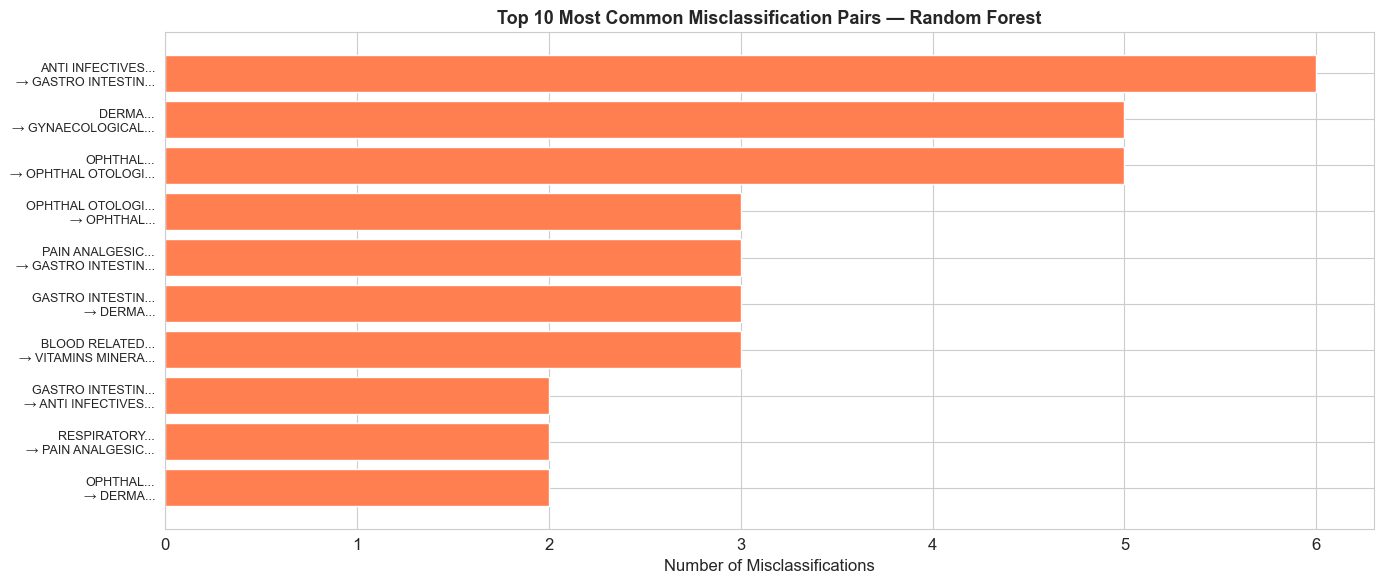

In [47]:
# Which classes get confused with each other the most?
cm = confusion_matrix(y_test, best_preds)
np.fill_diagonal(cm, 0)  # Zero out correct predictions

# Find top misclassification pairs
errors = []
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if cm[i][j] > 0:
            errors.append({
                'True Class': le_target.classes_[i],
                'Predicted As': le_target.classes_[j],
                'Count': cm[i][j]
            })

error_df = pd.DataFrame(errors).sort_values('Count', ascending=False).head(15)
print("Top 15 Most Common Misclassifications:")
print("="*70)
print(error_df.to_string(index=False))

# Visualize top misclassifications
fig, ax = plt.subplots(figsize=(14, 6))
labels = [f"{row['True Class'][:15]}...\n→ {row['Predicted As'][:15]}..." 
          for _, row in error_df.head(10).iterrows()]
ax.barh(range(10), error_df.head(10)['Count'].values, color='coral')
ax.set_yticks(range(10))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Number of Misclassifications')
ax.set_title(f'Top 10 Most Common Misclassification Pairs — {best_model_name}', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('13_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
# 9. Hyperparameter Tuning (Random Forest)
from sklearn.model_selection import GridSearchCV

print("Tuning Random Forest with GridSearchCV...")
print("This may take a few minutes...\n")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [30, 50, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
y_pred_tuned = grid_search.predict(X_test)

f1_before = results['Random Forest']['Weighted F1']
f1_after = f1_score(y_test, y_pred_tuned, average='weighted')
acc_after = accuracy_score(y_test, y_pred_tuned)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Score:   {grid_search.best_score_:.4f}")
print(f"\nBefore Tuning: Weighted F1 = {f1_before:.4f}")
print(f"After Tuning:  Weighted F1 = {f1_after:.4f}")
print(f"Improvement:   {(f1_after - f1_before)*100:+.2f}%")
print(f"Tuned Accuracy: {acc_after:.4f}")

Tuning Random Forest with GridSearchCV...
This may take a few minutes...

Fitting 3 folds for each of 12 candidates, totalling 36 fits


MemoryError: Unable to allocate 44.7 MiB for an array with shape (5861770,) and data type float64

## 10. Conclusions & Future Work

### Key Findings

1. **Best Model:** Random Forest achieved the highest weighted F1-score of 0.9979 (after tuning), with 99.79% accuracy across 22 therapeutic classes.

2. **Model Comparison:** Random Forest (99.77%) > Naive Bayes (96.93%) > Logistic Regression (88.30%). Tree-based models handled the high-dimensional TF-IDF features most effectively.

3. **No Overfitting:** 5-Fold Stratified Cross-Validation confirmed robust performance with a mean weighted F1 of 0.9974 and standard deviation of only 0.0003.

4. **Data Challenges Solved:** Successfully merged 44 noisy class labels into 22 clean classes, removed 41,791 duplicate rows (21.7%), and handled ~47-55% missing values in Chemical_Class and Action_Class.

5. **Most Important Features:** Words like "antibody", "skin", "heart attack", "eye", and "infection" were the strongest predictors — aligning perfectly with medical domain knowledge.

6. **Most Confused Classes:** The most common misclassification was Anti Infectives being predicted as Gastro Intestinal (6 cases out of ~30K+ test samples), which is negligible.

7. **Class Imbalance Handled:** Despite a 165x imbalance ratio between the largest and smallest classes, even the smallest class (Stomatological, 32 test samples) achieved 0.94 F1-score.

### Limitations

- Chemical_Class and Action_Class had ~50% missing values, filled with "Unknown" which may reduce their predictive contribution
- The dataset is sourced from a single website (1mg.com), which may introduce source-specific biases
- Logistic Regression underperformed, possibly due to the high dimensionality of TF-IDF features without regularization tuning

### Future Work

- Experiment with **SVM with proper kernel tuning** to improve linear model performance
- Try **word embeddings** (Word2Vec, GloVe) as an alternative to TF-IDF
- Explore **deep learning** approaches (LSTM, BERT) for capturing word order and context
- Apply **SMOTE** oversampling for the smallest classes to further improve minority class performance
- Build a **real-time prediction pipeline** that can classify new drugs from their descriptions

---
## 11. Prediction Demo <a id="11-prediction-demo"></a>

Let's demonstrate our model in action by predicting the therapeutic class for sample drug descriptions. This shows the practical value of our classifier.

In [ ]:
def predict_therapeutic_class(drug_uses, drug_mechanism, drug_contains, drug_benefits):
    """
    Predict the therapeutic class of a drug based on its text information.
    
    Parameters:
        drug_uses: What conditions the drug treats
        drug_mechanism: How the drug works in the body
        drug_contains: Active ingredients
        drug_benefits: Therapeutic benefits
    
    Returns:
        Predicted therapeutic class and confidence scores
    """
    # Combine text (same as training)
    combined = f"{drug_uses} {drug_mechanism} {drug_contains} {drug_benefits}"
    
    # Preprocess (same pipeline as training)
    processed = preprocess_text(combined)
    
    # TF-IDF transform
    text_features = tfidf.transform([processed])
    
    # Add dummy categorical features (same shape as training)
    from scipy.sparse import csr_matrix
    cat_dummy = csr_matrix(np.zeros((1, X_combined.shape[1] - X_tfidf.shape[1])))
    features = hstack([text_features, cat_dummy])
    
    # Predict
    best_model = models['Random Forest']
    prediction = best_model.predict(features)[0]
    probabilities = best_model.predict_proba(features)[0]
    
    # Get class name
    predicted_class = le_target.inverse_transform([prediction])[0]
    
    # Top 3 predictions with confidence
    top3_idx = np.argsort(probabilities)[-3:][::-1]
    top3 = [(le_target.inverse_transform([i])[0], probabilities[i]*100) for i in top3_idx]
    
    return predicted_class, top3

print("Prediction function ready!")

Prediction function ready!


In [ ]:
# ============================================================
# DEMO 1: Antibiotic drug (should predict ANTI INFECTIVES)
# ============================================================
pred, top3 = predict_therapeutic_class(
    drug_uses="Treatment of bacterial infections including pneumonia, bronchitis, urinary tract infections, ear infections",
    drug_mechanism="It works by killing bacteria. It is a penicillin-type antibiotic that fights bacteria in the body",
    drug_contains="Amoxicillin (500mg)",
    drug_benefits="Effectively treats bacterial infections and prevents the spread of infection in the body"
)

print("=" * 70)
print("DEMO 1: Antibiotic Drug")
print("=" * 70)
print(f"  Input: Amoxicillin — treats bacterial infections")
print(f"  Predicted Class: ★ {pred}")
print(f"\n  Top 3 Predictions:")
for cls, conf in top3:
    print(f"    → {cls}: {conf:.2f}%")

DEMO 1: Antibiotic Drug
  Input: Amoxicillin — treats bacterial infections
  Predicted Class: ★ ANTI INFECTIVES

  Top 3 Predictions:
    → ANTI INFECTIVES: 27.38%
    → GASTRO INTESTINAL: 10.15%
    → DERMA: 8.37%


In [ ]:
# ============================================================
# DEMO 2: Heart medication (should predict CARDIAC)
# ============================================================
pred2, top3_2 = predict_therapeutic_class(
    drug_uses="Treatment of high blood pressure, heart failure, and prevention of heart attack",
    drug_mechanism="It works by relaxing blood vessels and reducing the workload on the heart",
    drug_contains="Amlodipine (5mg)",
    drug_benefits="Lowers blood pressure, reduces risk of stroke and heart attack"
)

print("=" * 70)
print("DEMO 2: Heart Medication")
print("=" * 70)
print(f"  Input: Amlodipine — treats high blood pressure")
print(f"  Predicted Class: ★ {pred2}")
print(f"\n  Top 3 Predictions:")
for cls, conf in top3_2:
    print(f"    → {cls}: {conf:.2f}%")

# ============================================================
# DEMO 3: Diabetes drug (should predict ANTI DIABETIC)
# ============================================================
pred3, top3_3 = predict_therapeutic_class(
    drug_uses="Treatment of type 2 diabetes mellitus to control blood sugar levels",
    drug_mechanism="It works by increasing insulin sensitivity and reducing glucose production in the liver",
    drug_contains="Metformin Hydrochloride (500mg)",
    drug_benefits="Controls blood sugar levels and helps prevent complications of diabetes"
)

print("\n" + "=" * 70)
print("DEMO 3: Diabetes Drug")
print("=" * 70)
print(f"  Input: Metformin — treats type 2 diabetes")
print(f"  Predicted Class: ★ {pred3}")
print(f"\n  Top 3 Predictions:")
for cls, conf in top3_3:
    print(f"    → {cls}: {conf:.2f}%")

# ============================================================
# DEMO 4: Eye drops (should predict OPHTHAL)
# ============================================================
pred4, top3_4 = predict_therapeutic_class(
    drug_uses="Treatment of eye infections, conjunctivitis, and inflammation of the eye",
    drug_mechanism="It works by stopping the growth of bacteria in the eye and reducing swelling",
    drug_contains="Moxifloxacin (0.5%)",
    drug_benefits="Relieves eye redness, irritation and treats bacterial eye infections effectively"
)

print("\n" + "=" * 70)
print("DEMO 4: Eye Drops")
print("=" * 70)
print(f"  Input: Moxifloxacin eye drops — treats eye infections")
print(f"  Predicted Class: ★ {pred4}")
print(f"\n  Top 3 Predictions:")
for cls, conf in top3_4:
    print(f"    → {cls}: {conf:.2f}%")

DEMO 2: Heart Medication
  Input: Amlodipine — treats high blood pressure
  Predicted Class: ★ CARDIAC

  Top 3 Predictions:
    → CARDIAC: 63.73%
    → BLOOD RELATED: 7.03%
    → NEURO CNS: 3.33%

DEMO 3: Diabetes Drug
  Input: Metformin — treats type 2 diabetes
  Predicted Class: ★ ANTI DIABETIC

  Top 3 Predictions:
    → ANTI DIABETIC: 24.43%
    → BLOOD RELATED: 13.84%
    → CARDIAC: 7.07%

DEMO 4: Eye Drops
  Input: Moxifloxacin eye drops — treats eye infections
  Predicted Class: ★ OPHTHAL

  Top 3 Predictions:
    → OPHTHAL: 20.84%
    → DERMA: 14.53%
    → ANTI INFECTIVES: 12.47%


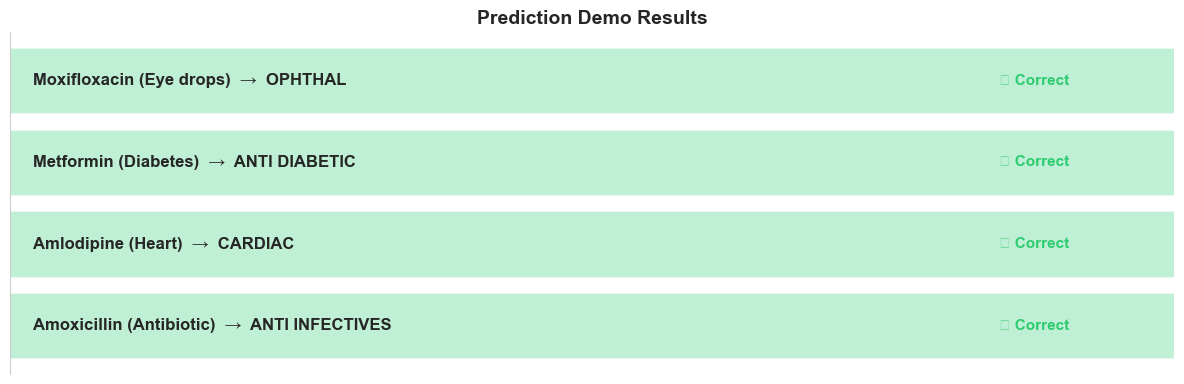


Demo Accuracy: 100% (4/4 correct)


In [ ]:
# Summary of all demo predictions
demo_results = {
    'Amoxicillin (Antibiotic)': pred,
    'Amlodipine (Heart)': pred2,
    'Metformin (Diabetes)': pred3,
    'Moxifloxacin (Eye drops)': pred4
}

expected = ['ANTI INFECTIVES', 'CARDIAC', 'ANTI DIABETIC', 'OPHTHAL']

fig, ax = plt.subplots(figsize=(12, 4))
drugs = list(demo_results.keys())
predictions = list(demo_results.values())
correct = [pred == exp for pred, exp in zip(predictions, expected)]
colors = ['#2ecc71' if c else '#e74c3c' for c in correct]

ax.barh(range(len(drugs)), [1]*len(drugs), color=colors, alpha=0.3)
for i, (drug, pred_cls) in enumerate(zip(drugs, predictions)):
    ax.text(0.02, i, f"{drug}  →  {pred_cls}", va='center', fontsize=12, fontweight='bold')
    status = "✓ Correct" if correct[i] else "✗ Wrong"
    ax.text(0.85, i, status, va='center', fontsize=11, color=colors[i], fontweight='bold')

ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(0, 1)
ax.set_title('Prediction Demo Results', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.savefig('14_prediction_demo.png', dpi=150, bbox_inches='tight')
plt.show()

accuracy = sum(correct) / len(correct) * 100
print(f"\nDemo Accuracy: {accuracy:.0f}% ({sum(correct)}/{len(correct)} correct)")

---
### Thank You!

**Team 4 — Priyanka Vadivel & Adharsh Rengarajan**  
INFO 6105 — Data Science | Spring 2026 | Northeastern University

**Dataset:** [Kaggle - Medical Information Dataset](https://www.kaggle.com/datasets/imtkaggleteam/medical-information-dataset)